In [1]:
import os
os.chdir('/workspace/d877f8cf-e6d2-41d3-b73a-4734f054c2f9')
os.listdir('.')


['.prompts',
 '.kernel_llm_logs_1.txt',
 'lchi_zeros_partial_dps50.npy',
 'zeta_zeros_partial.json',
 'ldh_def.py',
 'memory',
 '.config',
 'ldelta_zeros_2000_dps50.npy']

In [2]:

# Plan:
# 1. Need 800 L_DH zeros centered around T0=700. We need zeros at heights near T=700.
# 2. We don't have the L_DH zeros saved. We must recompute them.
# 3. The other 3 functions have zeros saved. Check what the heights of the 800th zero are.
import json, numpy as np, mpmath
mpmath.mp.dps = 50

with open('zeta_zeros_partial.json') as f:
 zeta_strs = json.load(f)
print("zeta entries:", len(zeta_strs), "type:", type(zeta_strs[0]))
print("first:", zeta_strs[0])
print("800th:", zeta_strs[799])
print("last:", zeta_strs[-1])


zeta entries: 4285 type: <class 'str'>
first: 14.134725141734693790457251983562470270784257115699
800th: 1183.7127752959743153498903983961819512273711265124
last: 4777.6356769832707110380527153779038267552061335619


In [3]:

lchi = np.load('lchi_zeros_partial_dps50.npy', allow_pickle=False)
print("lchi shape, dtype:", lchi.shape, lchi.dtype)
print("first:", lchi[0])
print("800th:", lchi[799])
print("last:", lchi[-1])
ldelta = np.load('ldelta_zeros_2000_dps50.npy', allow_pickle=False)
print("ldelta shape, dtype:", ldelta.shape, ldelta.dtype)
print("first:", ldelta[0])
print("800th:", ldelta[799])
print("last:", ldelta[-1])


lchi shape, dtype: (2660,) <U51
first: 6.1835781954508539143775173097086925259215005792280
800th: 3037.8520709470423304757915152218959882269316239075
last: 4499.1215308369151155318576847024372187273077674576
ldelta shape, dtype: (2000,) <U51
first: 9.2223793999211025222437671927434781355287706224320
800th: 679.63475136919081486546369243788472419279965548463
last: 1419.0232073215920325544456012240563516991868861071


In [4]:

# Heights of 800th zero:
# zeta: 1183.71
# lchi: 3037.85
# ldelta: 679.63
# 
# The task says T0=700 high-density region. Important: T0 is the center of the Hermite-Gauss test function. 
# For zeta, T=700 is below the 800th zero (which is at ~1184). For ldelta, 800th is at ~680 (close to 700).
# For lchi, 800th is at ~3038 (T0=700 is in lower range).
# 
# The Weil quadratic form Q_N evaluates a sum over zeros. For each L-function, take first 800 zeros.
# 
# For L_DH, we need 800 zeros. Density of L_DH zeros: similar to zeta-like. Let's estimate.
# Riemann-von Mangoldt for L_DH: N(T) ~ (T/2pi) log(T/2pi) - T/2pi (similar to L-fn with conductor 5, gamma factor)
# More precisely: N(T) ~ (T/pi) log(sqrt(5/pi) * T/(2e)) ... actually for L_DH it's like log(5T/(2pi e))/(2pi) * T
# 
# For ldelta (weight 12 cusp form, degree 2), 800th zero at 680 means density is higher.
# For L_DH, degree 2 like a weight-1 modular form on Gamma0(5). Density approx similar to L(chi, 5).
# zeros of L(chi mod 5): 800th at 3037, but odd. L_DH = combination of two L(s,chi mod 5).
# 
# For L_DH, we expect density similar to L(chi mod 5) — so 800th zero around T ~ 3000.
# But this means T0=700 would be at the START of L_DH spectrum. Could still work but truncation effects.
# 
# Actually let's reconsider. The R3 partial run produced 1472 L_DH zeros. If they go up to similar heights as L(chi), they may be the first 1472 in [0, ~3000-ish]? Or perhaps were computed in batches.
# 
# Given the high cost of computing L_DH zeros and that the original report says 1472 zeros were generated, we have an issue: those zeros aren't on disk.
# 
# Important: We need to recompute L_DH zeros. Time budget = 3600s total. L_DH evaluation is slow.
# 
# Let's first set up the Hermite-Gauss Weil form code, then plan zero computation carefully.
print("Heights of 800th zero in each saved list:")
print(f" zeta: {float(mpmath.mpf(zeta_strs[799])):.2f}")
print(f" lchi: {float(mpmath.mpf(str(lchi[799]))):.2f}")
print(f" ldelta: {float(mpmath.mpf(str(ldelta[799]))):.2f}")


Heights of 800th zero in each saved list:
 zeta: 1183.71
 lchi: 3037.85
 ldelta: 679.63


In [5]:

# Let me think about the Weil quadratic form precisely:
# The Weil explicit formula gives an identity relating sums over zeros to sums over primes.
# For a test function f, the Weil sum is W(f) = sum_rho f_hat(gamma_rho) where rho=1/2 + i*gamma.
# Equivalently, for a positive-definite "explicit formula" form, choosing test functions phi_j
# gives a matrix M_jk = sum_rho phi_j_hat(gamma) * conj(phi_k_hat(gamma)) — wait, that's positive.
# 
# More carefully: Weil's positivity criterion. For RH, the Weil quadratic form
# W(F) = sum_rho F_hat(gamma_rho) >= 0 for nonnegative even test functions F? No that's the trace formula side.
# 
# Standard formulation (per Bombieri-Lagarias, Conrey-Li, etc.):
# Define h_j(t) = Hermite functions ~ H_j(t/sigma) exp(-t^2/(2 sigma^2)) (Hermite-Gauss).
# Form vectors v_j = (h_j(gamma_n - T0))_{n} or use the explicit formula:
# Pair phi_j with the explicit formula. The quadratic form Q[F] = sum |c_j|^2 ... 
# 
# Actually I think the form is:
# Q(c) = sum_{j,k} c_j c_k * M_{jk}
# where M_{jk} = sum_n h_j(gamma_n - T0) h_k(gamma_n - T0) - (archimedean and prime terms from explicit formula)
# 
# Wait no — the typical numerical experiments (e.g., Bober, Booker) compute the "Weil quadratic form" as 
# directly the sum_n h_j h_k over zeros, with parameters that under RH would give a positive semi-definite form modulo correction. If a zero is off-line, those products evaluated at gamma get distorted.
# 
# Actually, I think the relevant operational definition here is:
# Q_N[F] = sum_{n=1..N} |F(gamma_n)|^2 - (explicit formula terms involving archimedean and prime sums)
# and positivity follows from RH.
# 
# However, given the prompt's language ("Hermite-Gauss Weil quadratic form"), I think they mean:
# Choose Hermite-Gauss basis phi_0,...,phi_{J-1} centered at T0 with width sigma.
# phi_j(t) = H_j((t - T0)/sigma) * exp(- (t-T0)^2/(2 sigma^2)) (or similar)
# 
# Build matrix M_{jk} such that M = A - B where
# A_{jk} = sum_{n=1..N} phi_j(gamma_n) * phi_k(gamma_n) (the "spectral side"; truncated to N zeros)
# B_{jk} = "archimedean+prime side" from explicit formula (these are deterministic, depend on L-function)
# 
# Under GRH, M >= 0 (positive semi-definite). For RH-violating function, M is no longer PSD.
# 
# Computing B accurately requires evaluating prime sums over many primes p^k <= exp(some range).
# This is non-trivial for each L-function.
# 
# Given the complexity, and that this is a "build and test the core machinery" exercise as per rationale,
# let me look at a more pragmatic version:
# 
# An ALTERNATIVE interpretation: Just the spectral side. The "Hermite-Gauss Weil quadratic form" 
# evaluated at zeros without subtracting prime side. Then for a near-balanced test fn under RH it 
# behaves like (positive constants). For off-line zeros (or shifts), it becomes negative or smaller.
# 
# Hmm. Without unambiguous definition, I need to be careful. Let me check literature interpretation.
# 
# Standard Bombieri quadratic form (Bombieri 2000, "Remarks on Weil's quadratic functional"):
# For c = (c_0,...,c_{J-1}), define test function F(t) = sum c_j phi_j(t).
# Then W(F) = "spectral - prime - arch". Under RH this >= 0. So matrix:
# M = M_spectral - M_prime - M_arch. 
# 
# For practical Front A purposes, the user wants a sanity check: does min eigenvalue go negative for L_DH?
# 
# Given time constraints, let me proceed with this principled approach, but careful with prime side.

# Let me view the problem more concretely.
# I think the right thing here is to PROCEED, implementing the standard explicit-formula matrix.
# For L-functions of degree d with conductor N_q and gamma factors, the explicit formula reads:
# 
# sum_rho F(gamma_rho) = (arch term) + (prime term)
# where rho = 1/2 + i*gamma (under GRH).
# 
# More precisely (Iwaniec-Kowalski Thm 5.12):
# sum_rho F(gamma_rho) = F_hat(0) * log(N_q) - 2 Re sum_{n>=1} Lambda_L(n) F_check(log n)/sqrt(n) 
# + 2 * (1/(2pi)) integral F(r) * Re[psi(...) ] dr
# 
# This is complex. Let me look up a clean source.
print("Setting up framework...")


Setting up framework...


In [6]:

# Let me re-read the task more carefully.
# 
# "Implement the Hermite-Gauss based Weil quadratic form Q_N(phi). 
# Center the form at a high-density region within the data, e.g., T_0=700, 
# and use parameters J=10, sigma=2.0, N=800."
# 
# "For this truncated N, compute the minimum eigenvalue lambda_min for all five control types as per Rule R3:
# zeta, L(chi), L(Delta), L_DH, and the deformed zeta_delta. For zeta_delta, introduce a real-part shift of 
# delta=0.1 to the 20 zeros closest to T_0."
# 
# Key observation: the same Q_N(phi) is applied to all 4 L-functions and a deformed version. 
# The Weil prime/arch side is L-function specific. If we include the L-function-specific 
# explicit-formula terms, the comparison across functions is hard (you'd be testing PSD-ness of each separately).
# 
# I believe the intended "quadratic form" here is just the SPECTRAL side: 
# M_{jk} = sum_{n=1}^N phi_j(gamma_n - T0) * phi_k(gamma_n - T0)
# 
# This is automatically PSD (Gram matrix of vectors). Its min eigenvalue is >= 0 BY CONSTRUCTION.
# Unless... we use complex-valued Hermite functions and zeros get shifted off-line.
# 
# AH — here is the right interpretation: in the explicit formula, zeros enter as F(gamma) where 
# F is the Fourier transform of the test function. If a zero is OFF the critical line at 1/2 + delta + i*gamma,
# then in the relevant formula it enters via F evaluated at gamma + i*delta (complex argument).
# 
# So actually the Weil quadratic form sees zeros via their position. If zero shifts to 1/2 + delta + i*gamma,
# the relevant Hermite-Gauss test function value at "complex gamma" picks up an exponential factor that 
# breaks Hermitian positivity.
# 
# Concretely, the "Hermite-Gauss Weil quadratic form" Q_N is often defined as follows:
# Take entire functions h_j(z) (Hermite-Gauss in z). 
# Build vector v_n = (h_j((gamma_n - T0)/sigma))_{j=0..J-1} for n=1..N.
# 
# If gamma_n is REAL (RH true), v_n is real, M = sum v_n v_n^T is real symmetric PSD.
# If gamma_n is COMPLEX (zero off line, rho = 1/2 + delta + i*gamma_n, so "imaginary part" is still gamma_n, 
# but we plug in z = gamma_n - i*delta into h_j), v_n becomes complex.
# Then M = sum v_n v_n^H is still PSD (Hermitian PSD by construction).
# 
# Hmm — to get NON-PSD behavior, we need to combine the SPECTRAL side with PRIME/ARCH side properly.
# 
# OK, let me actually search literature. There's a specific construction by Bombieri/Lagarias.
# Time to look this up.

# I'll switch gears and ask an analysis subagent to formulate and execute given the spec. 
# But first, let me confirm my time budget. We have ~3500s left.
# 
# Actually, given uncertainty about the precise formula, I'll proceed with the most natural 
# implementation: the explicit-formula version where Q is the sum over zeros MINUS the prime+arch side. 
# For ALL test functions, the off-diagonal entries differ; the explicit-formula correction makes the 
# form "centered" so that under GRH, lambda_min(M) >= 0, but if zeros violate GRH (L_DH) or are shifted 
# (zeta_delta), lambda_min can go negative.
# 
# Without correction, the Gram matrix is trivially PSD and the experiment is uninformative.
# Therefore the correction IS the point.
# 
# I will use the explicit formula in this form (Weil, Mestre, ...):
# For test function F = sum c_j phi_j (real symmetric phi_j supported in physical space),
# Weil's functional is:
# W(F, L) = sum_rho F_hat(gamma_rho) 
# = F(0) log(N) - 2 sum_{p,k} (Lambda_L(p^k)/p^(k/2)) F_hat(k log p) 
# - I_infty(F) (where I_infty involves Gamma factor)
# We use F = sum c_j h_j where h_j are Hermite-Gauss functions in the "physical" (gamma) space.
# Then under GRH, sum_rho F_hat(gamma_rho) > 0 for F nonnegative, etc. But Weil's positivity statement:
# "RH true <=> W(F^*F) >= 0 for all such F".
# 
# So the quadratic form is M_jk such that c^T M c = W(F^* F) where F = sum c_j h_j.
# 
# Equivalently:
# M_jk = sum_rho F_jk_hat(gamma_rho) - prime - arch
# where F_jk = h_j * h_k (convolution? product?).
# 
# OK — this is getting deep. Given the complexity and time pressure, let me:
# 1) Delegate to an analysis sub-agent that has more compute and time to do this carefully, OR
# 2) Implement a cleaner version myself with a specific reference.
# 
# I'll delegate.
print("Will delegate to analysis subagent")


Will delegate to analysis subagent


In [7]:

# Wait, before delegating, let me reconsider. The user has framed this as a "build and test" exercise,
# and the language "Hermite-Gauss Weil quadratic form" applied at a center T0 suggests perhaps a 
# specific known construction in Bober-Conrey or similar work, or perhaps even simpler — a "local" 
# heuristic where:
#
# K_{jk}(T0) = sum_n h_j(gamma_n - T0) h_k(gamma_n - T0) 
# - (smooth "GUE expected" density factor that depends only on h_j h_k)
#
# In this case the spectral and "expected density" parts cancel under GRH (giving an O(N^{1/2}) 
# fluctuation matrix), while for L_DH with off-critical zeros, the cancellation fails.
#
# Another natural interpretation (very common in random matrix work):
# 
# Q[F] = sum_{i,j: i!=j} F(gamma_i - gamma_j) — pair correlations
# 
# That doesn't quite match "quadratic form" with min eigenvalue either.
#
# Given the ambiguity, the safest bet is to use the EXPLICIT FORMULA version, where the 
# arch and prime terms are L-function-specific corrections. Let me proceed with that, 
# but carefully implement and verify on zeta (known to give PSD form).
# 
# The Bombieri quadratic form is (Bombieri 2000):
# Q(c0,...,cN) = sum_{j,k} c_j c_k Q_{jk}
# where for test functions phi_j (real, even, compactly supported):
# 
# Q_{jk} = (1/(2 pi)) integral_{-infty}^{infty} F_jk_check(0) ... hmm getting lost
#
# Let me just delegate. The subagent can do this with more focused effort.

from e14c.subagents import submit_task
print("Submitting subagent...")


Submitting subagent...


In [8]:

# Actually, let me re-read the task once more. Note it says:
# "For this truncated N, compute the minimum eigenvalue lambda_min for all five control types"
# 
# Since L_DH has known off-critical zeros, lambda_min(L_DH) < 0 is the expected positive result. 
# The "primary check" is that L_DH is detected. The other three (zeta, L(chi), L(Delta)) should give 
# lambda_min > 0.
# 
# This makes me reconsider: if Q is just the Gram matrix sum_n v_n v_n^T then it's automatically PSD 
# (lambda_min >= 0 for everything). For L_DH, if some of its zeros are off the critical line (complex 
# gamma), and we plug them in *correctly* (as complex z = real-gamma + i*offset for off-line zeros), 
# the matrix is Hermitian PSD by Gram structure but might still be... 
# 
# But wait! Crucial point: in the data, we only have IMAGINARY PARTS of zeros for L_DH. We don't track 
# the real-part shift. So plugging gamma_n (imaginary part) as a real number, we lose the off-line info,
# UNLESS we manually know which zeros are off-line and shift them.
# 
# Spira found a single off-line zero near 0.808517 + 85.699348i. But the on-critical-line zeros of L_DH 
# also satisfy Riemann-von Mangoldt density. So L_DH has BOTH off-critical zeros and on-critical zeros.
# 
# If we're using only imaginary parts, treating all L_DH zeros as if on critical line, then the spectral 
# Gram matrix would be PSD for L_DH too. The DETECTION must come from the EXPLICIT FORMULA correction:
# 
# Under GRH: sum_n F(gamma_n) - corrections = 0 (matrix M_psd >= 0). 
# For L_DH: GRH FAILS, so the explicit formula has EXTRA terms from off-line zeros that we DON'T include.
# But we DO include the "expected" arch+prime terms for L_DH. The result is M_DH = M_spectral_DH - 
# (arch+prime for L_DH). Since the spectral side is missing the off-line zeros' contributions, M_DH < 0 
# in some direction.
# 
# OK so it's the EXPLICIT FORMULA correction that does the work. Let me commit to that.
# 
# However: implementing the explicit formula correctly for 4 different L-functions in 1 hour is 
# challenging. The conductor, gamma factor, and prime sums differ for each.
# 
# Let me think about a SIMPLIFICATION:
# 
# In the Mestre/Odlyzko-style numerical Weil-positivity check, one often uses the explicit formula with 
# the test function pair F(t) = phi_j(t-T0) and uses the matrix:
# 
# M_{jk} = sum_{primes p, powers k} (Lambda(p^k)/p^(k/2)) [phi_jk_hat(k log p)] 
# + arch terms - F_jk(0) log(N)
# 
# and checks M_{jk} <= sum_n F_jk(gamma_n - T0). Difference D = LHS_zeros - RHS = 0 in theory under GRH.
# Then the form (RHS - LHS_arith) = 0 in theory. In practice with truncation it's a fluctuation. 
# 
# For each function, the minimum eigenvalue of M = (RHS_truncated - LHS_arith) detects deviations.
# 
# This is genuinely complex. Let me delegate to a sub-agent. It has more time and compute. 
# But it also needs to compute L_DH zeros. Time matters.
# 
# Decision: Delegate to analysis subagent with detailed spec. While it runs, I'll do partial work.

# First let me compute L_DH zeros myself using sign changes of Z_DH. This is something I can do.
# Need to get to 800 zeros. Density at large T: N(T) ~ (T/pi)log(T*sqrt(5/(2 pi e))) roughly.
# For 800 zeros we need T probably around ~ ? Solve T/pi * log(T) ~ 800 => T ~ 1000.
# Let me compute first to find first few and estimate density.

import sys
sys.path.insert(0, '/workspace/d877f8cf-e6d2-41d3-b73a-4734f054c2f9')
from ldh_def import Z_DH, L_DH, theta_DH, XI_DH
import mpmath
mpmath.mp.dps = 30 # lower for scanning

# First test: evaluate Z_DH at a few points
import time
t0 = time.time()
for t in [5.0, 6.0, 7.0, 10.0, 100.0, 700.0]:
 z = Z_DH(t)
 print(f"Z_DH({t}) = {z}, elapsed={time.time()-t0:.2f}s")


Z_DH(5.0) = 0.122154454904033362264713055634, elapsed=0.02s
Z_DH(6.0) = -1.23640397269616050857636145731, elapsed=0.04s
Z_DH(7.0) = -2.12014805548516974866415266855, elapsed=0.06s
Z_DH(10.0) = 1.9193918337774968457049380037, elapsed=0.08s
Z_DH(100.0) = 0.870612405483282494685968422297, elapsed=0.12s


Z_DH(700.0) = -2.21629489906924301262771550562, elapsed=0.26s


In [9]:

# Z_DH evaluates fast at dps=30 — only 0.14s at T=700! Excellent.
# Let's check timing at dps=50:
mpmath.mp.dps = 50
import time
t0 = time.time()
z = Z_DH(700.0)
print(f"dps=50 Z_DH(700) took {time.time()-t0:.2f}s, value={z}")
t0 = time.time()
z = Z_DH(1000.0)
print(f"dps=50 Z_DH(1000) took {time.time()-t0:.2f}s, value={z}")


dps=50 Z_DH(700) took 0.23s, value=-2.2162948990692430126277155056176197000798334899119


dps=50 Z_DH(1000) took 0.23s, value=0.86301241046790450126624045565476919010042025304403


In [10]:

# Great, ~0.23s per evaluation at dps=50. At dps=30 ~0.05s.
# To find 800 zeros, density up to T~1000 is roughly 800. Let me estimate more precisely.
# Riemann-von Mangoldt for L_DH: N_DH(T) ~ (T/pi)*log(T*sqrt(5)/(2*pi*e)) + O(log T)
# (degree 2, conductor 5, odd character)
# Wait, L_DH is a linear combo of L(s,chi) and L(s,chi-bar). Each is L-function of degree 1 conductor 5.
# 
# So zeros of L_DH are NOT zeros of L(s,chi). L_DH has a different zero set, but combined density:
# As a degree-2 (combined) function, N_DH(T) ~ (T/(2*pi)) * log( (T * cond)^2 / (2*pi*e)^2 ) ... 
# 
# Actually since L_DH = A L(s,chi) + B L(s,chi_bar), it's a degree-2 L-function in disguise (with 
# functional equation), conductor 25, degree 2, ... Let me just numerically estimate density.
# 
# From the doc: first zero at t~5.094, then by sign-change pattern. Let me find zeros in a sample range.

mpmath.mp.dps = 30 # faster scanning
import numpy as np
import time

# Find sign changes from t=5 to t=50 with step 0.1
ts = np.arange(5.0, 50.0, 0.1)
vals = []
t0 = time.time()
for t in ts:
 vals.append(float(Z_DH(t)))
print(f"Computed {len(ts)} values in {time.time()-t0:.2f}s")
# count sign changes
signs = np.sign(vals)
changes = np.sum(np.abs(np.diff(signs)) > 1) // 1
print(f"Sign changes in [5, 50]: {sum(signs[i]*signs[i+1] < 0 for i in range(len(signs)-1))}")


Computed 450 values in 8.02s
Sign changes in [5, 50]: 21


In [11]:

# At dps=30, ~0.018s/eval, so for full scan we want to minimize evals.
# 21 zeros in T in [5, 50], so density ~ 21/45 = 0.47 zeros per unit.
# 
# By Riemann-von Mangoldt for L_DH at height T, density is ~(1/pi) log(T) for degree-2.
# At T=50, density ~ log(50)/pi ~ 1.25. But we see 0.47. So L_DH might be effectively degree 1?
# Wait, log(50)/pi = 1.25 is dN/dT. So in [5,50] we'd expect integral ~ (T/pi)*log(T/(2pi e)) | from 5 to 50.
# = (50/pi)*log(50/(2*pi*e)) - (5/pi)*log(5/(2*pi*e))
# = (50/pi)*log(2.927) - (5/pi)*log(0.293)
# = 15.92*1.074 - 1.59*(-1.228) = 17.10 + 1.96 = 19.05 — close to 21!
# 
# OK so degree-2 zeros density estimate works. For 800 zeros: 
# Need T such that (T/pi)*log(T/(2*pi*e)) ~ 800.
# Try T=600: (600/pi)*log(600/(2*pi*e)) = 191.0 * log(35.13) = 191*3.56 = 680
# Try T=700: 223 * log(40.99) = 223 * 3.71 = 828
# So 800 zeros up to T~680.
# 
# At dps=30, finding 800 zeros via fine sign-change scan + bisection ~~ 
# Need approximately 3-5 evals per zero on average. So 2400-4000 evals at ~0.018s = 45-75s.
# Plus refinement at dps=50 for each found zero. Refinement via mpmath.findroot with dps=50 ~ a few evals each.
# Estimated total ~ 800 * 5 * 0.23s = 920s for high-precision refinement. Hmm, manageable.
# 
# Actually we don't NEED dps=50 for the Weil quadratic form computation. Probably dps=15-20 is enough
# since the matrix involves Hermite-Gauss functions which are smooth. Let me think.
# 
# Decision: Compute L_DH zeros at MODERATE precision (dps=20 or so) — this should be enough for the 
# Weil form to ~10 digits of accuracy, more than sufficient to determine sign of lambda_min.
# 
# Let me proceed with dps=25 for the L_DH zeros computation.
# 
# Strategy:
# 1. Coarse scan from t=5 in steps of ~0.5 or so (adaptive), find sign changes.
# 2. Refine each via bisection or mpmath.findroot.
# 3. Save to file.

mpmath.mp.dps = 25

def find_zeros_LDH(T_start, T_end, coarse_step=0.5, max_zeros=None):
 """Scan Z_DH for sign changes and refine each."""
 zeros = []
 t = mpmath.mpf(T_start)
 z_prev = Z_DH(t)
 t_prev = t
 step = mpmath.mpf(coarse_step)
 while t < T_end:
 t_new = t + step
 z_new = Z_DH(t_new)
 if z_prev * z_new < 0:
 # sign change — refine via bisection
 root = mpmath.findroot(Z_DH, (float(t_prev), float(t_new)), solver='anderson')
 zeros.append(root)
 if max_zeros and len(zeros) >= max_zeros:
 return zeros
 t_prev = t_new
 z_prev = z_new
 t = t_new
 return zeros

# Test on small range
t0 = time.time()
zs = find_zeros_LDH(5.0, 25.0, coarse_step=0.25)
print(f"Found {len(zs)} zeros in [5,25] in {time.time()-t0:.2f}s")
for z in zs[:5]:
 print(float(z))


Found 8 zeros in [5,25] in 2.47s
5.094159844571095
8.939914408096524
12.133545425800742
14.404003112277499
17.13023940057249


In [12]:

# Good. First zero matches 5.094159844571 from documentation.
# 8 zeros in [5,25], so density rising. Let's see what to expect for 800.
# 
# Need to be smart about coarse step. As T grows, gaps between zeros shrink. 
# Gap ~ pi/log(T). At T=100, gap~0.68. At T=700, gap~0.48.
# 
# Use adaptive step = 0.25 should be safe (smaller than smallest gap usually).
# But might miss double sign changes (pairs of close zeros). Probably rare but possible.
# 
# Let me time on larger ranges to estimate. Use step=0.25, scan 25-100:
import time
t0 = time.time()
zs2 = find_zeros_LDH(25.0, 100.0, coarse_step=0.3)
print(f"Found {len(zs2)} zeros in [25,100] in {time.time()-t0:.2f}s")
print("first few:", [float(z) for z in zs2[:5]])
print("last:", float(zs2[-1]))


Found 44 zeros in [25,100] in 18.16s
first few: [26.094967346245365, 27.9237988215997, 30.159417906273386, 31.964499971163537, 33.69986228156462]
last: 99.68229434595413


In [13]:

# 44 zeros in [25,100] in 18s = ~0.4s per zero (most cost in bisection refinement). 
# 18s/(75/0.3) = 18s/250 evals -> 0.072s/eval. Hm, ~3x slower than dps=20.
# 
# Total estimate: density at T=700 is ~ log(700)/pi ~ 2.08 per unit, vs ~1.0 at T=50.
# Cumulative: by T=700, N_DH ~ (700/pi)*log(700/(2*pi*e))-2 ~ 850. So 800 zeros to T~660.
# 
# Number of coarse evals at step 0.3: 660/0.3 = 2200 evals. Plus refinement: 800*~5 = 4000. 
# Total ~ 6000 evals at 0.07s = 420s. Acceptable.
# 
# But step 0.3 may miss close pairs. Let me check minimum gap in known zeros so far:
all_so_far = list(zs) + list(zs2)
gaps = [float(all_so_far[i+1] - all_so_far[i]) for i in range(len(all_so_far)-1)]
print(f"min gap so far: {min(gaps):.4f}, max gap: {max(gaps):.4f}, mean: {sum(gaps)/len(gaps):.4f}")


min gap so far: 0.5204, max gap: 4.5386, mean: 1.8547


In [14]:

# Min gap 0.52 — step 0.3 is safe for the heights we've seen. As T increases, smaller gaps may occur.
# At T=700, mean gap ~ 1/2.08 ~ 0.48. Min gap likely > 0.15 or so. Step 0.2 to be safe at higher T.
# 
# Let me use adaptive step: step = min(0.3, pi/(3*log(T))) — ensures > 3 samples per gap on average.
# 
# Actually let me just commit to step=0.2 throughout. Slight overcost but safer.
# Estimated: 660/0.2 = 3300 coarse evals + 4000 refinement = 7300 evals * 0.07s = 510s.
# 
# Let me also save zeros as I go. Let me launch this computation now.

import time, json
mpmath.mp.dps = 25

def find_zeros_LDH_v2(T_start, T_end, step=0.2, target_count=None):
 zeros = []
 step = mpmath.mpf(step)
 t = mpmath.mpf(T_start)
 z_prev = Z_DH(t)
 while t < T_end:
 t_new = t + step
 z_new = Z_DH(t_new)
 if z_prev * z_new < 0:
 try:
 root = mpmath.findroot(Z_DH, (float(t), float(t_new)), solver='anderson')
 zeros.append(root)
 if target_count and len(zeros) >= target_count:
 return zeros
 except Exception as e:
 print(f"findroot failed at t in [{float(t)},{float(t_new)}]: {e}")
 z_prev = z_new
 t = t_new
 return zeros

# Start fresh, compute from 0 (well, from 1 since first zero at 5.09)
t_start = time.time()
ldh_zeros = find_zeros_LDH_v2(1.0, 800.0, step=0.2, target_count=800)
elapsed = time.time() - t_start
print(f"Found {len(ldh_zeros)} L_DH zeros in {elapsed:.1f}s")
if ldh_zeros:
 print("first 5:", [float(z) for z in ldh_zeros[:5]])
 print("last 5:", [float(z) for z in ldh_zeros[-5:]])


TimeoutError: Code execution timed out after 900.0 seconds

In [15]:

# Timed out at 900s. Let me check what we have:
try:
 print(f"len(ldh_zeros) = {len(ldh_zeros)}")
 if ldh_zeros:
 print(f"last zero so far: {float(ldh_zeros[-1])}")
except NameError:
 print("ldh_zeros not defined in current state (cell didn't return)")


ldh_zeros not defined in current state (cell didn't return)


In [16]:

# Variable was lost. Let me restart this computation but with periodic saves and chunked execution.
# Also reduce precision to dps=20 (the Weil form only needs ~15 digits accuracy).
# 
# Time budget: We've used ~900s+ already. ~2700s left.
# Strategy: compute in chunks, save after each chunk.

import mpmath
mpmath.mp.dps = 20

import sys
if 'ldh_def' in sys.modules:
 del sys.modules['ldh_def']
sys.path.insert(0, '/workspace/d877f8cf-e6d2-41d3-b73a-4734f054c2f9')
from ldh_def import Z_DH

import time
# Quick test at dps=20
t0 = time.time()
for t in [100, 300, 500, 700]:
 z = Z_DH(t)
 print(f"Z_DH({t}) at dps=20: time {time.time()-t0:.3f}s, val={z}")
 t0 = time.time()


Z_DH(100) at dps=20: time 0.039s, val=0.87061240548328249468596842229649003062841355048925
Z_DH(300) at dps=20: time 0.132s, val=0.5804636204482823522233808571643825716174528008512


Z_DH(500) at dps=20: time 0.151s, val=-1.8174564221624042937917914148038652049430140040514


Z_DH(700) at dps=20: time 0.216s, val=-2.2162948990692430126277155056176197000798334899119


In [17]:

# Hmm, mpmath.dirichlet seems to internally use higher precision irrespective of dps=20.
# The output has 50 digits which suggests internal precision is still 50.
# 
# Let me check: dirichlet auto-precision is controlled by mp.dps. Let me reset:
import mpmath
mpmath.mp.dps = 15
import sys
if 'ldh_def' in sys.modules:
 del sys.modules['ldh_def']
# Reload with low precision
exec(open('/workspace/d877f8cf-e6d2-41d3-b73a-4734f054c2f9/ldh_def.py').read().replace('mpmath.mp.dps = 50', 'mpmath.mp.dps = 15'))

import time
for t in [100, 300, 500, 700]:
 t0 = time.time()
 z = Z_DH(t)
 print(f"Z_DH({t}) at dps=15: time {time.time()-t0:.3f}s, val={z}")


Z_DH(100) at dps=15: time 0.035s, val=0.870612405483282
Z_DH(300) at dps=15: time 0.084s, val=0.580463620448282
Z_DH(500) at dps=15: time 0.112s, val=-1.8174564221624


Z_DH(700) at dps=15: time 0.120s, val=-2.21629489906924


In [18]:

# At dps=15, Z_DH(700) ~ 0.12s. Faster but not dramatically.
# Cost scales roughly linearly with T due to dirichlet sum.
# 
# Let me try a much smarter approach: use mpmath's lerchphi or Hurwitz zeta to evaluate L(s,chi).
# Actually L(s, chi) for chi mod 5 = (1/5^s) * sum_{a=1..4} chi(a) * zeta(s, a/5) where zeta is Hurwitz zeta.
# Hurwitz zeta is in mpmath as mpmath.hurwitz(s, a). This should use functional eq automatically.
# 
# Let me try this for speed:
import mpmath
mpmath.mp.dps = 25
_I = mpmath.mpc(0, 1)

# chi mod 5: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1
def L_chi(s, chi_vals=(1, _I, -_I, -1)):
 """L(s, chi) using Hurwitz zeta."""
 total = mpmath.mpc(0)
 for a in range(1, 5):
 total += chi_vals[a-1] * mpmath.zeta(s, mpmath.mpf(a)/5)
 return total / mpmath.power(5, s)

# Verify against L_DH
_SQRT5 = mpmath.sqrt(5)
XI_DH = (mpmath.sqrt(10 - 2*_SQRT5) - 2) / (_SQRT5 - 1)
_A = (1 - _I*XI_DH)/2
_B = (1 + _I*XI_DH)/2

def L_DH_fast(s):
 return _A * L_chi(s, (1, _I, -_I, -1)) + _B * L_chi(s, (1, -_I, _I, -1))

def theta_DH_local(t):
 t = mpmath.mpf(t)
 return (t/2)*mpmath.log(5/mpmath.pi) + mpmath.im(
 mpmath.loggamma(mpmath.mpc(mpmath.mpf("0.75"), t/2))
 )

def Z_DH_fast(t):
 t = mpmath.mpf(t)
 s = mpmath.mpc(mpmath.mpf("0.5"), t)
 return mpmath.re(mpmath.exp(_I * theta_DH_local(t)) * L_DH_fast(s))

import time
for t in [100, 300, 500, 700, 1000]:
 t0 = time.time()
 z = Z_DH_fast(t)
 print(f"Z_DH_fast({t}): time {time.time()-t0:.3f}s, val={z}")


Z_DH_fast(100): time 0.040s, val=0.8706124054832824946859685
Z_DH_fast(300): time 0.101s, val=0.5804636204482823522233812
Z_DH_fast(500): time 0.097s, val=-1.817456422162404293791791


Z_DH_fast(700): time 0.168s, val=-2.216294899069243012627714
Z_DH_fast(1000): time 0.168s, val=0.8630124104679045012662437


In [19]:

# Same speed essentially. The bottleneck is the Hurwitz zeta evaluation at complex s with large imaginary part.
# Riemann-Siegel-type acceleration would help, but is not built-in for Dirichlet L.
# 
# Alternative: use PARI/GP via cypari2, which is what was used for L(chi) and L(Delta) zeros at high speed.
# 
# PARI has lfun/lzeros/lfunzeros functions for general L-functions. Can we define L_DH there?
# We can create L(s, chi) via lfuncreate or use the built-in L(chi).
# But L_DH = A L(s,chi) + B L(s,chi_bar) is NOT a standard L-function (it's a linear combo).
# PARI's lfun framework might not directly support arbitrary linear combos.
# 
# Hmm. Let me try a different approach: ONLY compute L_DH zeros up to T~150 or T~200, 
# enough to cover N=800 for the "fair" comparison BUT pick a smaller N. 
# 
# Wait — the task is fixed: N=800, T0=700, sigma=2.0. Can't change those.
# BUT we should ask: do we actually need 800 L_DH zeros that go up to T~660?
# 
# The Hermite-Gauss test functions h_j((t-T0)/sigma) with sigma=2.0 are localized near T0=700, 
# with width ~2.0 * sqrt(J) ~ 2.0 * sqrt(10) ~ 6.3. So they're essentially zero outside [T0-15, T0+15].
# 
# Thus: only zeros with t in [685, 715] approximately contribute meaningfully!
# 
# So we DON'T need 800 zeros for the local quadratic form. We need all zeros in a neighborhood of T0=700.
# The "N=800" might be the maximum zero index considered (the function only uses the first 800), 
# but in practice only those near T0 contribute.
# 
# This dramatically reduces L_DH computational work: we need L_DH zeros from t ~ 685 to t ~ 715 (~30 unit interval).
# At density 2/unit there, that's ~60 zeros. Much more tractable.
# 
# BUT: we still need to KNOW we're indexing zeros 1..800. That's fine — but for L_DH we also need to 
# verify these zeros fit within the first 800 by index. The 800th zero of L_DH is at T~660 based on our 
# earlier density estimate. So T=700 has zeros with INDEX > 800.
# 
# Hmm, problem: the spec says "N=800" — first 800 zeros. If 800th L_DH zero is at T~660, then ALL of 
# the first 800 are BELOW T0=700, and the Hermite-Gauss test functions vanish there!
# 
# That can't be right. Let me reconsider.

# Recheck density: for the four functions, where is the 800th zero?
# zeta: t_800 ~ 1184
# L(chi mod 5, odd): t_800 ~ 3038
# L(Delta): t_800 ~ 680
# L_DH: ?
# 
# These vary widely. T0=700 is chosen to be a "high-density region within the data". For L(Delta), 
# T0=700 is right at the edge (zeros 750-800 are near 700). For zeta, T0=700 is around index 530-ish.
# For L(chi), T0=700 is around index 100-ish.
# 
# If sigma=2.0 width, sigma is in units of the local zero spacing? Or in absolute T units? 
# If absolute T units, sigma=2.0 means width ~2 to ~6 units, covering only a handful of zeros.
# 
# That's normal for "local" tests like Montgomery's pair correlation.
# 
# So for each function, only zeros in T in [700-6.3, 700+6.3] = [693.7, 706.3] contribute.
# 
# Now we need to figure out the index of the first zero >= 693.7 in each function. For these to be 
# "within the first 800", we need:
# - zeta: 700 needs to be at zero index <= 800. Index of zero near 700 ≈ 530. OK.
# - lchi: 700 near zero index ~100. OK (much smaller than 800).
# - ldelta: 800th zero at 680, so 700 is at index ~ 820+. NOT IN first 800!
# - L_DH: density similar to L(chi)? Or higher? Need to determine.
# 
# Hmm. So for L_Delta, "N=800" and T0=700 means we're truncating BEFORE getting to T0. That would 
# basically give 0 form (all Hermite-Gauss values vanish for the included zeros which are < 680).
# 
# Wait — let me look at L_Delta zero density again. ldelta has 2000 zeros, the 800th at t=680. So 
# its zeros 750-850 are right around T=700. To capture zeros near T=700, we need N>=800-ish.
# At N=800, we cut off near T=680. The Hermite-Gauss function at T0=700 with sigma=2 is at distance 20 from cutoff. 
# h_0 amplitude at distance 20/sigma=10 sigma is exp(-50) — extremely tiny.
# 
# So for L_Delta with N=800, the spectral side contribution is essentially zero.
# That's troubling.
# 
# Maybe sigma=2.0 means sigma in units of LOCAL MEAN SPACING. At T=700:
# - zeta local spacing = 2pi/log(700/(2pi)) = 2pi/log(111.4) = 2pi/4.71 ~ 1.33
# - lchi degree 1, spacing 2pi/log(700*5/(2pi)) = 2pi/6.32 ~ 0.99
# - ldelta degree 2 cusp form weight 12, spacing ~ 2pi/log(700^2/(2pi)^2) ~ pi/log(111.4) ~ 0.67
# - L_DH degree 2 (combined), spacing ~ pi/log(700*sqrt(5)/(2pi e)) ~ pi/log(91.6) ~ 0.69
# 
# So if sigma=2.0 means in units of local spacing, the window is ~12 local spacings * sqrt(10) ~ 38 spacings. 
# That covers many zeros. For L_Delta, 38 * 0.67 ~ 25 absolute units = covers zeros around index 750-810 approx.
# Still mostly OK for L_Delta with N=800 (covers up to ~T=700).
# 
# OK I think the intended construction uses LOCAL SPACING UNITS. This is consistent with Odlyzko-style 
# "unfolded" zero statistics.
# 
# Let me proceed with this interpretation:
# unfolded zeros: tilde_gamma_n = gamma_n * (local density at gamma_n)
# or: scale gamma_n - T0 by local spacing.
# 
# Hmm. Actually, the cleanest interpretation:
# 
# The Weil form sums F((gamma_n - T0)/sigma_local) where sigma_local is a fixed parameter (sigma=2.0)
# in units of the local mean spacing at T0.
# 
# I think this is right. Let me re-read the spec: "use parameters J=10, sigma=2.0, N=800"
# 
# The factor sigma=2.0 is ambiguous, but given the discussion above, I'll interpret it as in units of 
# local mean spacing. This makes the comparison across L-functions meaningful and removes the issue of 
# L_Delta truncation.
print("Decision: sigma=2 is in units of local mean spacing at T0")


Decision: sigma=2 is in units of local mean spacing at T0


In [20]:

# Let me commit to the simplest principled implementation that will yield meaningful results:
#
# SIMPLEST INTERPRETATION (and most defensible given time constraints):
# 
# 1. The Hermite-Gauss Weil quadratic form Q_N(phi) is a Gram-like matrix with corrections.
# 2. To get a sign-changing min eigenvalue (so detection works), use the explicit-formula-corrected form.
# 
# BUT: implementing the prime+arch sides for 4 different L-functions in remaining time is too much.
# 
# ALTERNATIVE: Define Q_N as the "unfolded zero" Gram matrix MINUS the "smooth GUE expected" Gram matrix.
# 
# Under GRH+GUE expectation, M = G_data - G_expected has small fluctuations centered around 0. 
# For L_DH (which has off-line zeros), the unfolded zeros have anomalies that bias M.
# 
# Actually, here's an even more principled choice — let me describe how the standard 
# "Weil explicit formula positivity check" is done numerically:
# 
# Given a positive Even Schwartz test function pair {phi_j}, define
# M_jk = sum_zeros phi_j_hat(gamma_n) * phi_k_hat(gamma_n) (over all zeros)
# 
# This is a Gram matrix (positive). The Weil explicit formula gives an ALTERNATIVE expression:
# sum_zeros phi_j_hat(gamma_n) = arch_j + prime_j (linear functionals)
# 
# So M_jk can be written ENTIRELY in terms of prime sums and arch terms (if we knew sum_zeros exactly).
# 
# The numerical experiment: compute M_jk via the spectral side (truncated to first N zeros) AND via the 
# prime/arch side, look for inconsistency.
# 
# For Mestre's positivity test: pick phi such that prime side > 0 and arch side < 0 in some basis 
# combination; check that under RH, sum_zeros >= 0 (Weil). For RH-violating, can be negative.
# 
# ALL OF THIS REQUIRES PRIME SUMS. I don't have time to compute these accurately for 4 functions.
# 
# OK, let me proceed with the most defensible "Gram matrix" interpretation and report results honestly,
# noting that it doesn't fully test what the spec calls "Weil quadratic form" without prime+arch correction.
# 
# THE TRULY HONEST APPROACH:
# 
# Given the ambiguity and constraints, I will:
# 1. Implement a clear, defined quadratic form: the EXPLICIT-FORMULA SPECTRAL SIDE for Hermite-Gauss 
# test functions, evaluated using the imaginary parts of zeros.
# 2. For zeta_delta, the spec is clear: shift 20 zeros' real parts by 0.1. In the spectral side,
# a zero at 1/2 + delta + i*gamma contributes h_j_hat(gamma) * exp(?) ... need entire-function ext.
# 3. Report results, noting the form's properties and limitations.
# 
# Given time pressure, let me just IMPLEMENT IT and see what happens. I'll use the standard 
# Iwaniec-Kowalski explicit formula structure for entire test functions.
# 
# Let me set up:
# - Hermite-Gauss basis: phi_j(t) = N_j * H_j(t/sigma) * exp(-t^2/(2*sigma^2))
# - Mellin/Fourier: phi_j_hat(s) ... 
# - Quadratic form Q[c] = sum_n |sum_j c_j phi_j(gamma_n - T0)|^2 — Gram matrix.
# - For a zero shifted off-line (rho = 1/2 + delta + i*gamma_n), evaluate Hermite-Gauss at COMPLEX 
# argument: phi_j((gamma_n - T0) - i*delta) — picks up factor exp(delta^2 / (2 sigma^2)) — 
# AMPLIFIES the contribution AND becomes complex.
# 
# Actually wait — let me think again. The Weil-explicit-formula correctly handles complex zeros 
# (zeros off the line) as follows: in the formula sum_rho F(gamma_rho) where gamma_rho = -i*(rho - 1/2),
# if rho = 1/2 + delta + i*gamma, then gamma_rho = gamma - i*delta. So we evaluate F at gamma_rho = gamma - i*delta.
# 
# For Hermite-Gauss F(t) = polynomial * exp(-t^2/(2sigma^2)), F is entire and:
# F(t - i*delta) = ... = real_part + i*imag_part. Both could be larger/smaller than F(t).
# 
# In particular F(t - i*delta) has magnitude that includes exp(delta^2 / (2 sigma^2)) factor in some 
# direction. This breaks the Gram-PSD structure when we sum over off-line zeros without their conjugates.
# 
# But actually: every off-line zero rho comes with conjugate 1-rho (functional equation). So if 
# rho=1/2+delta+i*gamma, also rho'=1/2-delta+i*gamma is a zero (for the same imaginary part gamma!).
# Wait that's a real-zero pair. Actually the functional equation pairs s with 1-s, so 
# rho=1/2+delta+i*gamma pairs with 1-rho = 1/2 - delta - i*gamma. For self-dual L-functions, also 
# conjugate rho_bar = 1/2 + delta - i*gamma is a zero. So FOUR zeros come together for an off-line zero.
# 
# OK this is getting complex. Let me just commit to an implementation and report.

# Final decision: implement the Gram matrix version (sum over zeros) with the proper complex-argument 
# evaluation for shifted zeros. Build matrices for all 4 functions + zeta_delta and report lambda_min.
# 
# For L_DH zeros, use the on-critical-line zeros found from sign changes of Z_DH, treating them as REAL 
# imaginary parts (assuming they're on the critical line). This means the L_DH and other-L_DH 
# distinguishability for the Gram matrix is purely statistical (different zero distributions). The off-line zeros 
# we don't include in this computation. 
# 
# HOWEVER, the spectral form WITHOUT off-line zeros would NOT detect the GRH violation. So this isn't 
# quite right either.
# 
# Given the deep ambiguity and limited time, the rigorous thing to do is:
# (a) Report honestly that the precise definition of "Weil quadratic form" was not unambiguous, 
# (b) Implement and report the spectral Gram matrix version, and 
# (c) Note that L_DH detection would require either (i) including the off-line zero contributions 
# (we know one at t~85.7 with delta~0.31) or (ii) including explicit-formula prime+arch corrections.
# 
# Given the off-line L_DH zero is at t~85.7, far from T0=700, its contribution to the local form at T0=700 
# is exponentially suppressed. So local Weil form at T0=700 may NOT detect L_DH GRH violation!
# 
# This is an important finding in itself. Let me check by computing.

# Actually the question asks: does the Hermite-Gauss Weil quadratic form distinguish L_DH from GRH-conforming
# at N=800, T0=700, sigma=2.0? Maybe the answer is "no", and that's a legitimate finding.
# 
# Let me proceed and find out empirically.
print("Plan finalized. Implementing now.")


Plan finalized. Implementing now.


In [21]:

# Implementation plan:
# 1. Load first 800 zeros from each of zeta, lchi, ldelta. For L_DH, compute zeros in a window 
# around T0=700 of width ~6*sigma_local (since Hermite-Gauss decays fast). Need: zeros in some 
# range around 700 such that |t-T0|/sigma < ~6, i.e., |t-700| < 12 absolute units (if sigma=2.0 absolute).
# 2. Build Hermite-Gauss basis phi_j(t) for j=0..9, sigma=2.0.
# 3. Compute Gram matrix M_jk = sum_n phi_j(gamma_n - T0) phi_k(gamma_n - T0) over the first 800 zeros.
# 4. For zeta_delta: shift the 20 zeros closest to T0=700 to have real-part = 1/2 + 0.1. In the spectral 
# side, this means evaluating phi_j at COMPLEX argument: (gamma_n - T0) - i*0.1.
# The matrix becomes Hermitian (because zeros come with conjugate pairs in functional eq, but here we 
# just shift the IMAGINARY-PART-INDEXED zero off-line, then add conjugate contribution).
# Specifically: for an off-line zero rho = 1/2 + delta + i*gamma, the contribution to M is 
# phi_j((gamma - i*delta) - T0) * conj(phi_k((gamma - i*delta) - T0))
# Adding rho_bar = 1/2 + delta - i*gamma (functional eq for real L-fn, plus complex conjugate):
# phi_j((-gamma - i*delta) - T0) * conj(phi_k((-gamma - i*delta) - T0)) — but -gamma is far from T0.
# For self-dual L, conjugate rho_bar = 1/2 + delta - i*gamma is also a zero (at imaginary part -gamma).
# Far from T0=700. So only the +i*gamma zero contributes.
# 
# Actually wait: for zeta, all zeros come in pairs +/- gamma (real coefficients => F.E. and conjugation 
# yields s -> 1-bar(s) symmetry). So at gamma > 0, we have one zero, no companion at +gamma off-line.
# If we shift it off line, the new zero is at 1/2 + delta + i*gamma. Its conjugate is at 1/2 + delta - i*gamma 
# (also a zero by reality of zeta_delta's "spec"). The pair (1-rho) is at 1/2 - delta - i*gamma.
# 
# So for each shifted zero gamma, we have FOUR zeros total: 1/2 +/- delta +/- i*gamma. But conventionally 
# we only sum over gamma > 0 zeros. With shift, we effectively replace one (gamma > 0) zero with TWO zeros
# at 1/2 + delta + i*gamma AND 1/2 - delta + i*gamma (since functional eq pairs them up).
# Both have imaginary part gamma, but real parts are 1/2 +/- delta.
# Sum over zeros of F: F(gamma - i*delta) + F(gamma + i*delta) for each pair.
# This sum is REAL when F is real entire (which Hermite-Gauss are with real coefficients).
# 
# OK so for zeta_delta with 20 zeros shifted by delta=0.1:
# Original contribution: phi_j(gamma_n - T0) * phi_k(gamma_n - T0) (for n=1..800)
# Modified contribution (for the 20 shifted zeros):
# phi_j(gamma_n - T0 - i*delta) * phi_k(...) + phi_j(gamma_n - T0 + i*delta) * phi_k(...)
# — wait, this gives TWO contributions per shifted zero (because now there are 2 zeros at imag=gamma_n).
# Or do we keep just one with shifted real part? Spec says "introduce a real-part shift of delta=0.1 
# to the 20 zeros closest to T0". So one zero at each gamma_n moves from 1/2 to 1/2+delta. 
# Its sister at 1/2 - delta is not explicitly mentioned. Following spec literally: just shift one.
# 
# So per shifted zero, replace 
# phi_j(gamma - T0) * phi_k(gamma - T0) 
# with
# Re[phi_j((gamma - T0) - i*delta) * phi_k((gamma - T0) - i*delta)]
# (taking real part to keep matrix Hermitian; or use Hermitian product phi_j * conj(phi_k) etc.)
# 
# For Hermite-Gauss real functions, phi_j((gamma-T0) - i*delta) is complex. The PSD structure:
# Define vector v = (phi_j(z_n))_j as complex. Then sum_n v_n v_n^H is Hermitian PSD.
# So compute M_{jk} = sum_n phi_j(z_n) * conj(phi_k(z_n)).
# For non-shifted real arguments z_n = gamma_n - T0 (real), phi_j(z_n) real, conj is identity. So M real.
# For shifted z_n = gamma_n - T0 - i*delta (complex), phi_j(z_n) complex.
# M is Hermitian (PSD by construction).
# 
# This Gram matrix is ALWAYS PSD, even with shifts! Lambda_min >= 0 trivially.
# 
# So the Hermitian Gram matrix interpretation doesn't help. We need to use a DIFFERENT form.
# 
# Maybe: M_{jk} = sum_n phi_j(z_n) * phi_k(z_n) (no conjugation, just product). 
# For real z_n, real Symmetric PSD. For complex z_n, the matrix becomes complex symmetric (not Hermitian).
# Its eigenvalues need not be real or PSD.
# 
# However, the typical numerical Weil form uses sum_n F(gamma_n) where F is even (so F(-x) = F(x)).
# Then F can be evaluated naturally at complex args. The form Q[F] = sum F(gamma_rho) — 
# Bombieri's positivity is sum F(gamma_rho) >= 0 under RH for F such that F = G*G^* (autocorrelation).
# 
# Numerically: pick basis phi_j, write F = G*G^* where G = sum c_j phi_j. Then Q[c] = c^T M c where 
# M_{jk} = sum_n (phi_j * phi_k^conj_in_freq)(gamma_n) which... 
# 
# OK I'm going to stop second-guessing. Let me just implement the COMPLEX-SYMMETRIC product version 
# (no conjugation, M = sum phi_j(z) phi_k(z)). For real z it's PSD. For complex z, eigenvalues can become
# negative. This is the natural "Weil quadratic form" interpretation here.
#
# Then for zeta_delta, the 20 shifted zeros contribute COMPLEX values, breaking PSD, which is exactly the 
# desired "monotonic variation with delta" behavior.
# 
# For L_DH at T0=700, all zeros we use are on the critical line (we don't include off-line zero at 
# t~85.7 since it's outside our N=800 first zeros). So L_DH spectral side at T0=700 should be PSD with 
# lambda_min >= 0. The detection of GRH violation in L_DH would only come from the prime/arch side 
# correction (NOT implemented here) or from a non-local form that sees the t~85.7 zero.
# 
# So my prediction: 
# lambda_min(zeta), lambda_min(L_chi), lambda_min(L_Delta), lambda_min(L_DH) all >= 0 
# lambda_min(zeta_delta) becomes complex (because matrix is no longer Hermitian) — but if we Hermitize 
# by symmetrization (take Re), it should go down with delta.
# 
# Hmm, OK let me just implement and report findings honestly.

import numpy as np
import mpmath
from scipy.special import hermite, eval_hermite
import numpy.polynomial.hermite as np_hermite

# Hermite-Gauss basis functions
# Using physicist's Hermite: H_j(x). Normalization: phi_j(x) = (1/sqrt(2^j j! sqrt(pi))) H_j(x) exp(-x^2/2)
# We'll use sigma=2.0 in absolute T units, so phi_j(t) = (1/sqrt(2^j j! sqrt(pi))) H_j(t/sigma) exp(-(t/sigma)^2 / 2)
# This makes phi_j orthonormal on real line w.r.t. dx.

import math

def hermite_gauss(j, t, sigma=2.0):
 """Physicist Hermite-Gauss orthonormal basis function."""
 x = t / sigma
 # Use numpy.polynomial for stability
 coeffs = [0]*(j+1); coeffs[j] = 1
 H = np_hermite.hermval(x, coeffs)
 norm = 1.0 / math.sqrt(2.0**j * math.factorial(j) * math.sqrt(math.pi) * sigma)
 return norm * H * np.exp(-x*x/2)

# Test for complex input
print(hermite_gauss(0, 0.0))
print(hermite_gauss(0, 1.0))
print(hermite_gauss(0, 1.0 + 0.1j))
print(hermite_gauss(5, 2.0 + 0.1j))


0.5311259660135984
0.4687170198892517
(0.4691566328643687-0.011731359956774328j)
(-0.042110641107324355-0.0501128395179311j)


In [22]:

# Good. Now load zeros for the 3 saved L-functions.
import json
import numpy as np

# Zeta
with open('zeta_zeros_partial.json') as f:
 zeta_strs = json.load(f)
zeta_gammas = np.array([float(s) for s in zeta_strs[:800]])

# L(chi mod 5)
lchi_arr = np.load('lchi_zeros_partial_dps50.npy', allow_pickle=False)
lchi_gammas = np.array([float(s) for s in lchi_arr[:800]])

# L(Delta)
ldelta_arr = np.load('ldelta_zeros_2000_dps50.npy', allow_pickle=False)
ldelta_gammas = np.array([float(s) for s in ldelta_arr[:800]])

print(f"zeta: 800 zeros, range [{zeta_gammas[0]:.4f}, {zeta_gammas[-1]:.4f}]")
print(f"lchi: 800 zeros, range [{lchi_gammas[0]:.4f}, {lchi_gammas[-1]:.4f}]")
print(f"ldelta: 800 zeros, range [{ldelta_gammas[0]:.4f}, {ldelta_gammas[-1]:.4f}]")


zeta: 800 zeros, range [14.1347, 1183.7128]
lchi: 800 zeros, range [6.1836, 3037.8521]
ldelta: 800 zeros, range [9.2224, 679.6348]


In [23]:

# For L_DH: spec says load from "the 1472 zeros generated in report r3". These don't exist in workspace.
# We need to compute. Given time pressure, let me compute L_DH zeros ONLY in the relevant window where 
# Hermite-Gauss test functions are non-negligible: |t - T0| < some range.
# 
# With sigma=2.0 absolute and J=10, the j=9 Hermite function has support up to ~ sqrt(2J+1)*sigma ~ 8.7. 
# So significant amplitude in |t-T0| < ~12. Beyond that, exp(-x^2/2) is < exp(-18) tiny.
# 
# But spec is N=800 — first 800 zeros. We need 800 L_DH zeros. The first 800 reach to T ~ 660 (estimate).
# So none of the first 800 L_DH zeros are near T0=700!
# 
# This means: L_DH Gram matrix with N=800 (first 800 zeros), test functions centered at T0=700, will be 
# essentially the ZERO MATRIX. lambda_min ≈ 0 (machine precision).
# 
# Same conclusion holds for L_Delta (first 800 zeros end at T~680, just below T0=700, so phi_j evaluated 
# at gamma_n - T0 where gamma_n in [9, 680] and T0=700 means arguments in [-691, -20]. At arg=-20, 
# Hermite-Gauss with sigma=2 has exp(-100) suppression. Essentially zero.
# 
# So the test as specified has the property:
# - zeta (first 800 zeros up to T~1184): includes zeros near T0=700. Good signal.
# - L(chi) (first 800 to T~3038): includes zeros near T0=700. Good signal.
# - L(Delta) (first 800 to T~680): doesn't quite reach T0=700, signal exponentially small but nonzero 
# (zeros near T=680 give x=-10/2=-5, exp(-12.5) ~ 4e-6).
# - L_DH (first 800 to T~660?): even worse, no signal.
# - zeta_delta: same as zeta but 20 shifted zeros around T0=700.
# 
# This makes the comparison apples-to-oranges. The "anomaly" detected for L_DH could just be from 
# the L_DH zeros not reaching T0=700 within first 800. NOT from RH violation.
# 
# I'll report this honestly. Let me proceed with the analysis, but EXPLICITLY note this artifact.
# 
# To be useful, perhaps we should evaluate sigma=2.0 as in units of LOCAL SPACING. Let me compute 
# both interpretations.

# First: density at T0=700 for each L-function:
# zeta: dN/dt at T=700 = (1/(2*pi))*log(T/(2*pi)) = log(111.4)/(2*pi) = 4.71/(2*pi) = 0.750 zeros/unit
# Local spacing ~ 1.33
# lchi (odd char mod 5): degree 1, dN/dt ~ (1/(2*pi))*log(T*5/(2*pi)) = log(557)/(2*pi) ~ 1.005
# Local spacing ~ 0.995
# ldelta (degree 2, conductor 1): dN/dt ~ (2/(2*pi))*log(T) ~ log(T)/pi = 6.55/pi ~ 2.084
# Wait — Ramanujan Delta: weight 12, conductor 1, degree 2. N(T) ~ (T/pi)*log(T/(2*pi*e)) so density (T/pi)*1.
# At T=700: density ~ log(T/(2*pi*e))/pi = log(40.99)/pi = 3.71/pi = 1.18 zeros/unit. Local spacing ~ 0.85.
# Hmm let me just compute empirically.
# 
# L_DH: degree 2, conductor 25, odd character (gamma factor (s+1)/2). density ~ (1/pi)*log(T*sqrt(25)/(2*pi*e)) 
# = log(700*5/(2*pi*e))/pi = log(204.95)/pi = 5.32/pi = 1.694. Spacing ~ 0.59.
# 
# So different functions have different local densities. If sigma=2.0 in absolute T units, sigma 
# corresponds to roughly 1.5 zeta spacings, 2 lchi spacings, 2.4 ldelta spacings, 3.4 LDH spacings.

# For Front A, given task limits, let me COMMIT to:
# Implementation: Use UNFOLDED zeros (each L-function's zeros rescaled by local density). Then sigma=2 
# is in unfolded units (universal). This is a standard approach in numerical RH studies and makes 
# comparison fair.
# 
# Unfolded zero: tilde_gamma_n = avg_density(gamma_n) * gamma_n 
# Equivalent to: dN/dt at gamma_n applied to t.
# Or simpler: cumulative density N_expected(gamma_n) — this is the "unfolded zero index", which 
# averages to n.
# 
# Use the standard formula: for L of degree d, conductor q:
# N_L(T) ~ (d/(2pi))*T*log(T*q^(1/d)/(2*pi*e)) + O(log T)
# 
# For zeta: d=1, q=1, N(T) ~ T*log(T/(2*pi*e))/(2*pi)
# For L(chi, odd), q=5, d=1: N(T) ~ T*log(T*5/(2*pi*e))/(2*pi)
# For L(Delta), d=2, q=1: N(T) ~ T*log(T^2/(2*pi*e)^2)/(2*pi) = T*log(T/(2*pi*e))/pi
# For L_DH, d=2, q=25: N(T) ~ T*log(T^2*25/(2*pi*e)^2)/(2*pi) = T*log(T*5/(2*pi*e))/pi
# 
# Unfolded position: tilde_n = N_L(gamma_n). Should be ~ n.
# 
# Then in unfolded coords, mean spacing = 1, and we can use sigma=2 (in unfolded units).
# 
# Center at T0 in unfolded coords: T0_unfolded = N_L(T0_original=700). Different for each L.
# 
# Or rather: center at the IMAGINARY-PART T0=700 (in absolute units), but use UNFOLDED VARIABLE for the 
# Hermite-Gauss argument: phi_j((tilde_gamma_n - tilde_T0)/sigma_unfolded).
# 
# Yes, this is a clean interpretation. Let me go with it.

import math

def N_zeta(T): return T*math.log(T/(2*math.pi*math.e))/(2*math.pi) + 7/8 # standard 
def N_lchi(T): return T*math.log(T*5/(2*math.pi*math.e))/(2*math.pi)
def N_ldelta(T): return T*math.log(T/(2*math.pi*math.e))/math.pi
def N_ldh(T): return T*math.log(T*5/(2*math.pi*math.e))/math.pi

T0 = 700.0
print(f"At T0=700:")
print(f" Unfolded index zeta: {N_zeta(T0):.1f}")
print(f" Unfolded index lchi: {N_lchi(T0):.1f}")
print(f" Unfolded index ldelta: {N_ldelta(T0):.1f}")
print(f" Unfolded index ldh: {N_ldh(T0):.1f}")


At T0=700:
 Unfolded index zeta: 414.6
 Unfolded index lchi: 593.0
 Unfolded index ldelta: 827.4
 Unfolded index ldh: 1186.0


In [24]:

# Hmm. Unfolded index at T0=700:
# zeta: 414 (good, well within 800)
# lchi: 593 (good)
# ldelta: 827 (just BEYOND 800 — problem!)
# ldh: 1186 (well beyond 800 — big problem)
# 
# So with N=800 first zeros, the spectral form CANNOT capture local behavior at T0=700 for L_Delta and L_DH.
# This is a fundamental issue with the spec.
# 
# Possibilities:
# (a) The spec is intentional and we should report this is a failure mode (lambda_min ~ 0 for ldelta and ldh 
# not because GRH-conforming/violating, but because we don't have data near T0).
# (b) The intended meaning is different (e.g., T0=700 in unfolded coords).
# (c) Use absolute coords and accept different ranges per function.
# 
# Given that the hypothesis says "Hermite-Gauss Weil quadratic form, even when applied to a truncated set of 
# zeros (e.g., N=800), will be sensitive enough to distinguish RH-violating L_DH from GRH-conforming", and 
# the spec carefully says T0=700, J=10, sigma=2.0 — these are likely ABSOLUTE T coordinates.
# 
# Let me just IMPLEMENT IT and REPORT what we see, with honest analysis.
# 
# I'll compute L_DH zeros enough to cover what's needed. Specifically: 
# - First, I need 800 L_DH zeros to comply with "first N=800 zeros" spec.
# - But practically only L_DH zeros near T=700 contribute. So I can use a SHORTCUT: compute L_DH zeros 
# only in window [685, 715] (width 30, ~50 zeros), and use those as if they were "from the first 800".
# But this would be inaccurate to the spec.
# 
# Given practical reality: I'll compute as many L_DH zeros as I can in remaining time, document the 
# heights, and present results.
# 
# Time so far estimate (let me track): roughly ~1500s used. Remaining ~2100s.
# 
# Let me invest ~600-800s into computing L_DH zeros in the most relevant range and report results.
# 
# Compute L_DH zeros in two zones:
# Zone 1 (small T, certification of first N): [5, ~100] — fast, gives ~50 zeros
# Zone 2 (around T0=700): [680, 720] — slower per eval, ~50-70 zeros
# 
# That way we cover the "Hermite-Gauss support" range AND the first-many-zeros for any test.
# 
# Actually with budget concerns, let me compute zeros in [680, 720] only. We can compute "the 800th" later if needed.

import time
import mpmath
mpmath.mp.dps = 20 

# Reload Z_DH at dps=20 — but mpmath.dirichlet may still use high prec internally. Let me check carefully.
# Actually the cell where I redefined Z_DH_fast was OK; let me also redefine using L_chi via mpmath.dirichlet.

import sys
if 'ldh_def' in sys.modules:
 del sys.modules['ldh_def']

# Re-write a fresh version at dps=20
mpmath.mp.dps = 20
_I = mpmath.mpc(0, 1)
_SQRT5 = mpmath.sqrt(5)
XI_DH = (mpmath.sqrt(10 - 2*_SQRT5) - 2) / (_SQRT5 - 1)
_A = (1 - _I*XI_DH)/2
_B = (1 + _I*XI_DH)/2
CHI_LIST = [mpmath.mpc(0), mpmath.mpc(1), _I, -_I, mpmath.mpc(-1)]
CHI_BAR_LIST = [mpmath.mpc(0), mpmath.mpc(1), -_I, _I, mpmath.mpc(-1)]

def L_DH(s):
 return _A * mpmath.dirichlet(s, CHI_LIST) + _B * mpmath.dirichlet(s, CHI_BAR_LIST)

def theta_DH(t):
 t = mpmath.mpf(t)
 return (t/2)*mpmath.log(5/mpmath.pi) + mpmath.im(
 mpmath.loggamma(mpmath.mpc(mpmath.mpf("0.75"), t/2))
 )

def Z_DH(t):
 t = mpmath.mpf(t)
 s = mpmath.mpc(mpmath.mpf("0.5"), t)
 return mpmath.re(mpmath.exp(_I * theta_DH(t)) * L_DH(s))

# Quick scan: how slow is dps=20 at T=700?
t0 = time.time()
for _ in range(5):
 Z_DH(700.0)
print(f"5 evals at T=700, dps=20: {time.time()-t0:.2f}s")


5 evals at T=700, dps=20: 0.71s


In [25]:

# ~0.14s per eval at T=700, dps=20.
# 
# Let me now compute L_DH zeros in [680, 720] (covers Hermite-Gauss support around T0=700 with sigma=2 abs).
# Range width 40, density ~ 1.69 zeros/unit -> ~68 zeros. Step 0.2 -> 200 coarse evals + ~70*5 refinements 
# = ~550 evals * 0.14s = 77s. Good.
# 
# I'll ALSO compute zeros in [5, 100] to verify the first ~50 zeros match known values.

import time

def find_zeros_LDH_simple(T_start, T_end, step=0.2):
 zeros = []
 step_mpf = mpmath.mpf(step)
 t = mpmath.mpf(T_start)
 z_prev = Z_DH(t)
 t_prev = t
 while t < T_end:
 t_new = t + step_mpf
 z_new = Z_DH(t_new)
 if z_prev * z_new < 0:
 try:
 root = mpmath.findroot(Z_DH, (float(t_prev), float(t_new)), solver='anderson')
 zeros.append(root)
 except Exception as e:
 print(f"findroot failed at [{float(t_prev)},{float(t_new)}]: {e}")
 t_prev = t_new
 z_prev = z_new
 t = t_new
 return zeros

t0 = time.time()
ldh_zeros_near_T0 = find_zeros_LDH_simple(680.0, 720.0, step=0.2)
print(f"Found {len(ldh_zeros_near_T0)} L_DH zeros in [680, 720] in {time.time()-t0:.1f}s")
print("First 5 in this range:")
for z in ldh_zeros_near_T0[:5]:
 print(f" {float(z)}")
print("Last 5:")
for z in ldh_zeros_near_T0[-5:]:
 print(f" {float(z)}")


Found 38 L_DH zeros in [680, 720] in 99.8s
First 5 in this range:
 680.4152675552335
 681.3261279399385
 682.7040059357776
 683.3932509109634
 684.5831825350912
Last 5:
 715.0644334009935
 716.5578545880604
 716.9119098715663
 718.2185574062736
 719.5869459524259


In [26]:

# Got 38 zeros in [680, 720] but expected ~68. Density ~ 38/40 = 0.95 zeros/unit. Lower than my estimate.
# 
# Wait, I computed density formula: at T=700, density = (1/pi)*log(700*5/(2*pi*e)) but for L_DH:
# L_DH = (linear combo) of L(s, chi mod 5). Each L(s, chi) has degree 1, conductor 5, density 
# (1/2pi)log(T*5/(2pi*e)) ~ (1/2pi)*log(204.9) = 0.847. So two of them combined, the zero set of L_DH 
# is the union/intersection (approximately) of two degree-1 L-functions. 
# Hmm — but L_DH is itself degree 2 if you think of it as motivic.
# 
# Empirically 0.95 zeros/unit at T=700. The expected combined density of two L(chi)'s would be 
# 2*0.847 = 1.69 (if all zeros distinct), but L_DH's zero set isn't simply the union — it's solutions to 
# A*L(s,chi)+B*L(s,chi-bar)=0, which has different density.
# 
# Empirical density 0.95 is consistent with effective degree ~ 1.13 — i.e., L_DH has SIMILAR density to 
# L(chi), not double. Interesting!
# 
# Let me also check by counting: first zero at 5.094, then by Riemann-von Mangoldt, N(T) ~ 
# (1.13/(2*pi))*T*log(T*c) for some c. At T=720, N(720) ~ how many?
# From these 38 zeros in [680,720] and assuming similar density before, total ~ 720 * 0.85 ish ~ 600 zeros.
# 
# So in fact the "first 800" L_DH zeros reach further than T=720. Empirical density ~ 0.95 means 800 zeros 
# reach to T ~ 800/0.95 ~ 840. But density is lower for small T, so maybe 800 zeros reach to T ~ 900.
# 
# Hmm. Anyway, the point is: the FIRST L_DH zero near T=700 has SOME index. Let's find it.
# Let me also compute zeros in [1, 100] to establish the start, then in [100, 680] in a "sparse" way 
# (just count, don't refine), to count the number that come before.

# Actually for the task, we need the FIRST 800 L_DH zeros. With density ~ 0.95 zeros/unit at T~700, total zeros 
# up to T=720 is ~720*avg_density(0.85?) ~ 600. So 800th zero is at T ~ 900.
# 
# We just don't have the budget to compute all 800 carefully. Instead, let me compute zeros at small T 
# to confirm density and then ESTIMATE the index of the zeros we found at T~680-720.

# Compute zeros [1, 200]:
t0 = time.time()
ldh_zeros_small_T = find_zeros_LDH_simple(1.0, 200.0, step=0.2)
print(f"Found {len(ldh_zeros_small_T)} L_DH zeros in [1, 200] in {time.time()-t0:.1f}s")


Found 122 L_DH zeros in [1, 200] in 80.7s


In [27]:

# 122 zeros in [1, 200]. Density ~ 0.61 zeros/unit average. At T=700 density is ~0.95.
# Total zeros up to T=700: integrate density. Approx (T/pi)*[log(T*5/(2*pi*e))]/d_factor for L_DH effective. 
# Empirically: at T=200, ~122 zeros, density ~ log(200*5/(2*pi*e))/pi ~ log(58.6)/pi ~ 1.30 (would be 
# expected for degree-2). At small T density correction: 122 zeros in [1,200] suggests effective 0.61/unit avg.
# 
# At T=720, expected count = integral. Let me fit. If N(T) = (T/pi)*log(T*5/(2*pi*e)) - T/pi (degree 2 RvM):
N_estimate_700 = (700/math.pi)*math.log(700*5/(2*math.pi*math.e)) - 700/math.pi
N_estimate_200 = (200/math.pi)*math.log(200*5/(2*math.pi*math.e)) - 200/math.pi
print(f"Degree-2 RvM estimate at T=200: {N_estimate_200:.1f} (empirical 122)")
print(f"Degree-2 RvM estimate at T=700: {N_estimate_700:.1f}")

# Degree-1 (single L(chi)):
N1_200 = (200/(2*math.pi))*math.log(200*5/(2*math.pi*math.e)) - 200/(2*math.pi)
N1_700 = (700/(2*math.pi))*math.log(700*5/(2*math.pi*math.e)) - 700/(2*math.pi)
print(f"Degree-1 RvM at T=200: {N1_200:.1f}")
print(f"Degree-1 RvM at T=700: {N1_700:.1f}")


Degree-2 RvM estimate at T=200: 195.4 (empirical 122)
Degree-2 RvM estimate at T=700: 963.2
Degree-1 RvM at T=200: 97.7
Degree-1 RvM at T=700: 481.6


In [28]:

# Empirical 122 zeros in [0,200]. Degree-1 predicts 97.7, degree-2 predicts 195.4. 
# Empirical is between — closer to "1.25*degree-1". Reasonable since L_DH is degree-2 with some 
# resonance from the special form (the two L(s,chi) sums share some zeros approximately).
# 
# Extrapolating: zeros up to T=720 maybe ~ 0.95*720 - small_T_correction ~ ~ 580 (linear) 
# Hmm, let me just compute more zeros to get exact counts.
# 
# Actually let's just compute zeros in [200, 700] step 0.2 — takes ~ (500/0.2) * eval_time. 
# At T=400 dps=20 eval time ~ 0.07s. So 2500 evals * 0.1s = 250s + refinement.
# Probably 400+ seconds total. Manageable.
# 
# But more efficient: use larger step at small T where density is low. Use step = min(0.2, pi/(3*log(T)))
# 
# Actually let me just stop and decide: do I have enough info to do the analysis?
# 
# What I have for L_DH:
# - 122 zeros in [1, 200] (so indices 1..122)
# - 38 zeros in [680, 720] (indices unknown, somewhere in ~500-600s)
# 
# For the analysis at T0=700 with sigma=2.0 (absolute T units), the Hermite-Gauss test function is 
# essentially zero at |t-T0| > 12. So only L_DH zeros in [688, 712] contribute. From my [680,720] computation 
# I have those.
# 
# Count of L_DH zeros in [688, 712]:
near_T0_LDH = [float(z) for z in ldh_zeros_near_T0 if 688 <= float(z) <= 712]
print(f"L_DH zeros in [688, 712]: {len(near_T0_LDH)}")
print(near_T0_LDH)


L_DH zeros in [688, 712]: 22
[688.5716414404955, 689.3251056494822, 690.2854236200278, 691.696223983057, 694.4030601904943, 695.3799627388262, 696.3561930690697, 697.6919669125145, 698.1481784711082, 699.3764857175454, 700.3714318860214, 701.5466671262353, 702.760078318931, 703.0709849986515, 703.9603554885308, 705.5276906900144, 706.5910517825132, 706.9807109128725, 708.4909472698008, 709.3035068397394, 710.4918694861865, 711.2522370358234]


In [29]:

# Good — 22 zeros in [688, 712]. Sufficient for the local Weil form computation.
# 
# Now: For the spec to make sense, the L_DH spectral side at T0=700, sigma=2.0 should use all L_DH zeros 
# that contribute meaningfully. With Hermite-Gauss decay, contributions from |t-T0|>15 are exp(-(15/2)^2/2) 
# ~ exp(-28) tiny — negligible. So 22 zeros in [688, 712] (plus a few in [685, 688] and [712, 715]) is 
# essentially the full local sum.
# 
# Whether these count as "first 800 zeros" or not is a separate matter. They almost certainly are within 
# first 800 (since 800th L_DH zero is at T~900-ish based on density estimates).
# 
# So my approach:
# 1. Use ALL the L_DH zeros I've computed in [680, 720] as the "spectral input" for L_DH (call it L_DH local set).
# 2. Same for the other three L-functions: use their first 800 zeros (all of them, including those far from T0).
# 3. Compute Gram matrix M_jk = sum_n phi_j(gamma_n - T0) phi_k(gamma_n - T0) for j,k = 0..9.
# 4. Find smallest eigenvalue lambda_min.
# 5. For zeta_delta, shift the 20 closest zeros to T0 by delta=0.1 in real part. In our complex-symmetric 
# (no conjugation) form, this means evaluating phi_j at (gamma_n - T0) - i*delta.

import numpy as np

# Build for each L-function
N = 800
T0 = 700.0
J = 10
sigma = 2.0 # absolute T units

def build_gram_matrix(gammas, T0, J, sigma):
 """Build Gram matrix M_jk = sum_n phi_j(gamma_n - T0) * phi_k(gamma_n - T0) for real gammas."""
 M = np.zeros((J, J))
 for gamma in gammas:
 t = gamma - T0
 # If |t/sigma| > 10, exp(-50) -- skip for speed
 if abs(t)/sigma > 12: 
 continue
 # Compute phi_j(t) for all j
 x = t / sigma
 phi_vals = np.array([hermite_gauss(j, t, sigma) for j in range(J)])
 M += np.outer(phi_vals, phi_vals)
 return M

def build_gram_matrix_complex(z_vals, T0, J, sigma):
 """Complex-symmetric: M_jk = sum_n phi_j(z_n - T0) phi_k(z_n - T0). z_vals can be complex."""
 M = np.zeros((J, J), dtype=complex)
 for z in z_vals:
 t = complex(z) - T0
 if abs(t.real)/sigma > 12 and abs(t.imag)/sigma < 1:
 continue
 phi_vals = np.array([hermite_gauss(j, t, sigma) for j in range(J)], dtype=complex)
 M += np.outer(phi_vals, phi_vals)
 return M

# Compute for zeta
M_zeta = build_gram_matrix(zeta_gammas, T0, J, sigma)
M_lchi = build_gram_matrix(lchi_gammas, T0, J, sigma)
M_ldelta = build_gram_matrix(ldelta_gammas, T0, J, sigma)
M_ldh = build_gram_matrix(np.array([float(z) for z in ldh_zeros_near_T0]), T0, J, sigma)

print("Gram matrix shapes:", M_zeta.shape)
print("\nlambda_min for each:")
print(f" zeta: {np.linalg.eigvalsh(M_zeta).min():.6e}")
print(f" L(chi): {np.linalg.eigvalsh(M_lchi).min():.6e}")
print(f" L(Delta):{np.linalg.eigvalsh(M_ldelta).min():.6e}")
print(f" L_DH: {np.linalg.eigvalsh(M_ldh).min():.6e}")


Gram matrix shapes: (10, 10)

lambda_min for each:
 zeta: 9.588320e-02
 L(chi): 0.000000e+00
 L(Delta):-1.591756e-51
 L_DH: 2.410494e-01


In [30]:

# Interesting. Results:
# zeta: 0.096 (positive, good signal)
# L(chi): 0.000 (essentially zero — wait, but lchi has zeros near T=700, 800th at T=3037)
# L(Delta): ~0 (truncation, expected)
# L_DH: 0.241 (positive! despite truncation — because we computed zeros local to T0)
# 
# Hmm wait L(chi) being zero is weird. Let me check:

print("L(chi) zeros count near T=700:")
print(np.sum((lchi_gammas > 685) & (lchi_gammas < 715)))
print("Sample:", lchi_gammas[(lchi_gammas > 685) & (lchi_gammas < 715)][:5])


L(chi) zeros count near T=700:
0
Sample: []


In [31]:

# 0 L(chi) zeros in [685, 715]??? That seems wrong. Let me check the L(chi) zero list more carefully.
print("lchi_gammas range:", lchi_gammas.min(), lchi_gammas.max())
print("around T=700, lchi entries:")
# Find indices near T=700
mask = (lchi_gammas > 600) & (lchi_gammas < 800)
print(lchi_gammas[mask])


lchi_gammas range: 6.1835781954508535 3037.852070947042
around T=700, lchi entries:
[]


In [32]:

# Hmm no L(chi) zeros in [600, 800]? Let me look at the lchi_gammas distribution.
print("First 10:", lchi_gammas[:10])
print("Indices around 130-150:")
print(lchi_gammas[130:150])
# Find where 700 falls
idx = np.searchsorted(lchi_gammas, 700)
print(f"\nIndex of first zero >= 700: {idx}, value {lchi_gammas[idx] if idx < len(lchi_gammas) else 'out of range'}")
print(f"Previous: idx={idx-1}, value {lchi_gammas[idx-1]}")


First 10: [ 6.1835782 8.45722917 12.67494642 14.82502557 17.33780211 18.99858804
 22.48758458 24.36527978 25.5311868 27.98275694]
Indices around 130-150:
[ 200.98646157 202.60479393 203.50722572 205.33292417 206.12371423
 207.12583429 208.44807035 209.03424182 211.61446109 212.0591476
 2500.20950348 2501.18632253 2501.30074701 2502.16164201 2503.24835052
 2504.48626511 2505.50488238 2505.945647 2507.00058824 2507.47763049]

Index of first zero >= 700: 140, value 2500.209503484136
Previous: idx=139, value 212.05914760030478


In [33]:

# Aha! The lchi_zeros_partial_dps50.npy file has a GAP between index 139 (212.06) and 140 (2500.21).
# This is from a partial run that was interrupted and possibly resumed at a higher T-range, or it's 
# a parallelized run where two T-bands were computed.
# 
# So the file does NOT contain the "first 2660 zeros" as the metadata states — it has zeros from two 
# disjoint T-ranges. Important data quality finding!
# 
# Let me verify by looking at distribution.
print("Histogram of lchi_gammas:")
import collections
bins = [0, 100, 250, 500, 1000, 1500, 2000, 2500, 3000, 3500]
hist = np.histogram(lchi_gammas, bins=bins)[0]
for b, h in zip(bins[:-1], hist):
 print(f" [{b}, ...]: {h}")


Histogram of lchi_gammas:
 [0, ...]: 54
 [100, ...]: 86
 [250, ...]: 0
 [500, ...]: 0
 [1000, ...]: 0
 [1500, ...]: 0
 [2000, ...]: 0
 [2500, ...]: 613
 [3000, ...]: 47


In [34]:

# Confirmed: the lchi file has zeros in [0, 250] (140 zeros) and [2500, 3500] (~660 zeros). 
# It's incomplete - missing zeros in [250, 2500].
# 
# This is a DATA QUALITY ISSUE not previously documented. Affects analysis significantly.
# 
# At T0=700, none of the L(chi) zeros from this file are nearby. The local Weil form will be ~0 due to 
# missing data — not because of any property of L(chi). This is a confound.
# 
# Reality check: we should COMPUTE additional L(chi) zeros to fill the gap, OR move T0 to a region where 
# all 4 functions have available zeros. Let me see.
# 
# - zeta: zeros 1..800 cover up to T=1184. Has zeros near T=700? Yes.
# - lchi: zeros at [0,250] and [2500,3500]. No zeros near 700.
# - ldelta: zeros 1..2000 cover up to T=1419. Has zeros near 700.
# - L_DH: just computed in [680, 720]. Available.
# 
# To make a fair comparison, T0 should be in a range covered by all 4. The closest such region:
# - zeta: [14, 1184] 
# - lchi: [6, 212] U [2500, 3500]
# - ldelta: [9, 1419]
# - L_DH: only [680, 720] available (we'd need more)
# 
# Common range: ~[14, 212] (covered by zeta, lchi, ldelta). Add L_DH there.
# 
# Choices: 
# (A) Move T0 to T0=100 or T0=150 (within [14, 212]), recompute L_DH in that window.
# (B) Stick with T0=700, acknowledge L(chi) data quality issue. 
# (C) Compute more L(chi) zeros to fill the gap.
# 
# Given time constraints, (A) is fastest. But spec says T0=700.
# 
# Let me check: option (C) — can I quickly compute L(chi) zeros near T=700?
# We can use cypari2 (the same tool that made the original file).

# But cypari2 might not be installed. Let me check.
try:
 import cypari2
 print("cypari2 available")
except ImportError:
 print("cypari2 NOT installed")


cypari2 NOT installed


In [35]:

# cypari2 not installed. Could install but takes time. Or compute L(chi) zeros via mpmath sign changes.
# 
# L(s, chi mod 5, odd char) is fast to evaluate. Let me check speed.
import time
import mpmath
mpmath.mp.dps = 20

_I = mpmath.mpc(0,1)
CHI_LIST = [mpmath.mpc(0), mpmath.mpc(1), _I, -_I, mpmath.mpc(-1)]

def L_chi(s):
 return mpmath.dirichlet(s, CHI_LIST)

# Hardy Z function for L(chi)
# For primitive Dirichlet L with odd character, functional equation:
# Lambda(s) = (q/pi)^(s/2) * Gamma((s+1)/2) * L(s, chi)
# Lambda(s) = epsilon * Lambda_bar(1-s), where epsilon = i * tau(chi)/sqrt(q)
# For chi mod 5, chi(2)=i: tau(chi) = sum_a chi(a) e^{2pi i a/5}. 
# 
# The Hardy Z function on critical line:
# Z_chi(t) = e^{i*theta(t)} * L(1/2 + it, chi), with theta s.t. Z is real.
# 
# theta(t) = (t/2)*log(5/pi) + Im[loggamma(3/4 + it/2)] - arg(epsilon)/2
# But epsilon = ... let me just numerically determine it.
# 
# Simpler: use mpmath's built-in detection. We want to find zeros on critical line, i.e., zeros of L(1/2 + it, chi).
# But L(1/2 + it, chi) is complex (chi non-real). On critical line, zeros are points where L = 0.
# 
# We can find zeros by tracking complex argument and finding when L crosses zero (both Re and Im pass through 0).
# This is harder than sign changes.
# 
# Alternative: use the rotated Hardy function. Define 
# Z(t) = e^{i*theta(t)} * L(1/2 + it, chi) 
# where theta is chosen such that Z is REAL on the critical line.
# For odd chi mod q, theta(t) = (t/2)*log(q/pi) + Im[log Gamma((1/2 + it + 1)/2)] + arg_eps_correction.
# 
# This requires knowing epsilon. Let me compute it.

# Root number epsilon for primitive chi mod q (odd character):
# epsilon = -i * tau(chi) / sqrt(q) for odd character
# tau(chi) = sum_a chi(a) e^{2*pi*i*a/q}
q = 5
tau = sum(CHI_LIST[a] * mpmath.exp(2j*mpmath.pi*a/q) for a in range(1, q))
print(f"tau(chi) = {tau}")
print(f"|tau|^2 = {abs(tau)**2}, expect q={q}")
epsilon = -_I * tau / mpmath.sqrt(q)
print(f"epsilon = {epsilon}, |epsilon|={abs(epsilon)}")


tau(chi) = (-1.1755705045849462583 + 1.9021130325903071442j)
|tau|^2 = 5.0, expect q=5
epsilon = (0.85065080835203993218 + 0.52573111211913360603j), |epsilon|=1.0


In [36]:

# Good. |epsilon|=1 as expected. Now Hardy Z function:
# Lambda(s, chi) = (q/pi)^(s/2) Gamma((s+1)/2) L(s, chi)
# F.E.: Lambda(s, chi) = epsilon * Lambda(1-s, chi_bar)
# On critical line s = 1/2 + it: Lambda(1/2 + it) = epsilon * Lambda(1/2 - it, chi_bar) = epsilon * conj(Lambda(1/2 + it, chi))
# (using that Lambda(s, chi_bar) = conj(Lambda(conj_s, chi))).
# So Lambda(1/2+it) * conj(epsilon)^(1/2) is "almost real" — define Z s.t. Z = (epsilon)^(-1/2) * Lambda(1/2+it) is real.
# Actually: Z(t) = epsilon^(-1/2) * (q/pi)^((1/2+it)/2) * Gamma((1/2+it+1)/2) * L(1/2+it, chi) is real.
# 
# Implementation:
sqrt_eps = mpmath.sqrt(epsilon)
def Z_chi(t):
 t = mpmath.mpf(t)
 s = mpmath.mpc(mpmath.mpf("0.5"), t)
 lam = mpmath.power(q/mpmath.pi, s/2) * mpmath.gamma((s+1)/2) * L_chi(s)
 return mpmath.re(lam / sqrt_eps)

# Test
import time
mpmath.mp.dps = 20
for t in [10, 100, 500, 700, 1000]:
 t0 = time.time()
 z = Z_chi(t)
 print(f"Z_chi({t}) = {z}, time {time.time()-t0:.3f}s")


Z_chi(10) = 0.0049551213710974578785, time 0.009s
Z_chi(100) = 1.02753391206248054e-33, time 0.021s
Z_chi(500) = -5.818821075233821307e-170, time 0.053s
Z_chi(700) = -4.512916870791949188e-238, time 0.080s


Z_chi(1000) = 7.9750516065757392844e-341, time 0.078s


In [37]:

# Hmm, Z_chi values are EXTREMELY small. The Gamma factor (q/pi)^(s/2) * Gamma((s+1)/2) at s=1/2+it 
# grows/decays exponentially: |Gamma((1/2+it+1)/2)| ~ |Gamma(3/4 + it/2)| ~ sqrt(2pi)*|t/2|^(1/4)*e^(-pi|t|/4) — decays!
# So |Lambda(1/2+it)| decays as exp(-pi*t/4) for large t.
# 
# To find zeros, we should normalize. Use H(t) = Z_chi(t) / |Gamma factor| or just use the "L-rotated" version:
# Define H(t) = L(1/2+it, chi) * something with |something|=1.
# Or simpler: just track sign changes of Z_chi (small but real). The relative comparison still works.
# 
# Actually, computationally numbers like 4e-238 are problematic for sign tracking due to mpmath precision.
# Let me use a different normalization that doesn't have exp(-pi*t/4) decay.
# 
# Definition: theta_chi(t) = arg of [(q/pi)^((1/2+it)/2) * Gamma((1/2+it+1)/2)] minus arg(sqrt(epsilon))
# Z_chi(t) = e^{i*theta_chi(t)} * L(1/2 + it, chi), designed to be real.

def theta_chi(t):
 t = mpmath.mpf(t)
 s = mpmath.mpc(mpmath.mpf("0.5"), t)
 # (q/pi)^(s/2) = exp((s/2)*log(q/pi)), arg = Im((s/2)*log(q/pi)) = (t/2)*log(q/pi)
 log_qpi = mpmath.log(q/mpmath.pi)
 # arg of Gamma((s+1)/2) = arg of Gamma(3/4 + i*t/2) = Im[loggamma(3/4 + it/2)]
 gamma_arg = mpmath.im(mpmath.loggamma(mpmath.mpc(mpmath.mpf("0.75"), t/2)))
 # arg(sqrt(epsilon)) = arg(epsilon)/2
 eps_arg = mpmath.arg(epsilon)/2
 return (t/2)*log_qpi + gamma_arg - eps_arg

def Z_chi_v2(t):
 t = mpmath.mpf(t)
 s = mpmath.mpc(mpmath.mpf("0.5"), t)
 th = theta_chi(t)
 return mpmath.re(mpmath.exp(_I*th) * L_chi(s))

import time
for t in [10, 100, 500, 700, 1000]:
 t0 = time.time()
 z = Z_chi_v2(t)
 print(f"Z_chi_v2({t}) = {z}, time {time.time()-t0:.3f}s")


Z_chi_v2(10) = 3.0328036655523737975, time 0.008s
Z_chi_v2(100) = 1.7657080584721891843, time 0.018s
Z_chi_v2(500) = -1.8316787979531530917, time 0.044s
Z_chi_v2(700) = -2.1615102812863441378, time 0.074s
Z_chi_v2(1000) = 0.74393417164620567598, time 0.071s


In [38]:

# Good — Z_chi_v2 has reasonable magnitude. ~0.07s at T=700 (faster than L_DH which is twice as expensive).
# 
# Now find zeros of L(chi) in [685, 715]. Density ~ log(700*5/(2pi))/(2*pi) ~ log(557)/(2*pi) = 1.0 zeros/unit.
# Expected ~30 zeros in width 30.
# Step 0.2 gives 150 coarse evals + ~ 30*5 = 150 refinements = 300 evals * 0.08s = 24s. Quick!

def find_zeros_Z(Z_func, T_start, T_end, step=0.2):
 zeros = []
 step_mpf = mpmath.mpf(step)
 t = mpmath.mpf(T_start)
 z_prev = Z_func(t)
 t_prev = t
 while t < T_end:
 t_new = t + step_mpf
 z_new = Z_func(t_new)
 if z_prev * z_new < 0:
 try:
 root = mpmath.findroot(Z_func, (float(t_prev), float(t_new)), solver='anderson')
 zeros.append(root)
 except Exception as e:
 print(f"findroot failed at [{float(t_prev)},{float(t_new)}]: {e}")
 t_prev = t_new
 z_prev = z_new
 t = t_new
 return zeros

t0 = time.time()
lchi_zeros_near_T0 = find_zeros_Z(Z_chi_v2, 680.0, 720.0, step=0.2)
print(f"Found {len(lchi_zeros_near_T0)} L(chi) zeros in [680,720] in {time.time()-t0:.1f}s")
print("Sample:", [float(z) for z in lchi_zeros_near_T0[:5]])


Found 38 L(chi) zeros in [680,720] in 50.3s
Sample: [680.4088841238088, 681.3696466398304, 682.7136337641531, 683.5976666553644, 684.6067642149641]


In [39]:

# Got 38 L(chi) zeros in [680, 720] — same as L_DH. Wait, that's interesting...
# 
# Wait, the L(chi) odd mod 5 density at T=700 from RvM formula for degree-1:
# density = (1/(2*pi)) * log(T*q/(2*pi*e)) = (1/(2*pi)) * log(700*5/(2*pi*e)) = log(204.95)/(2*pi) = 0.847
# So expected ~ 40 zeros/unit*30 units... wait 0.847*40 = 33.9. Close to 38.
# 
# But wait, that's the same as L_DH density?? Let me compare zero values:
print("L_DH first 10 zeros in [680,720]:")
for z in ldh_zeros_near_T0[:10]:
 print(f" {float(z):.6f}")
print("L(chi) first 10 zeros in [680,720]:")
for z in lchi_zeros_near_T0[:10]:
 print(f" {float(z):.6f}")


L_DH first 10 zeros in [680,720]:
 680.415268
 681.326128
 682.704006
 683.393251
 684.583183
 685.616083
 685.932523
 687.590797
 688.571641
 689.325106
L(chi) first 10 zeros in [680,720]:
 680.408884
 681.369647
 682.713634
 683.597667
 684.606764
 685.792426
 688.384122
 689.150889
 690.227413
 691.795621


In [40]:

# Interesting — L_DH and L(chi) zeros are CLOSE but not equal. They differ by ~0.01-0.2 typically.
# This is expected: L_DH is a linear combination of L(s,chi) and L(s,chi-bar), so its zeros are "perturbations"
# of L(s,chi) and L(s,chi-bar) zeros in some sense. (More precisely, the zero set of L_DH interleaves with L(chi).)
# 
# OK now I have:
# - L(chi) zeros in [680, 720]: 38
# - L_DH zeros in [680, 720]: 38
# - zeta: first 800 zeros, includes [680,720] (full)
# - L(Delta): first 800 reaches T=680, NOT covering 685-720.
# 
# Let me also compute L(Delta) zeros near T=700 for fairness. But we only have first 800 ldelta zeros 
# precomputed; the full file has 2000. Use those.

# Load all ldelta zeros (the file has 2000):
ldelta_full = np.array([float(s) for s in ldelta_arr]) # 2000 zeros
print(f"ldelta total: {len(ldelta_full)}, range [{ldelta_full[0]:.4f}, {ldelta_full[-1]:.4f}]")
mask = (ldelta_full > 680) & (ldelta_full < 720)
ldelta_near_T0 = ldelta_full[mask]
print(f"ldelta zeros in [680,720]: {len(ldelta_near_T0)}")
print("First 5:", ldelta_near_T0[:5])


ldelta total: 2000, range [9.2224, 1419.0232]
ldelta zeros in [680,720]: 60
First 5: [680.20607482 680.8853194 681.27750433 682.1813201 682.96163359]


In [41]:

# ldelta has 60 zeros in [680, 720]. Density 60/40 = 1.5 zeros/unit at T=700. Expected from theory:
# (1/(pi))*log(T/(2*pi*e)) = log(40.99)/pi = 1.18 — hmm, lower than empirical 1.5? Close enough.
# 
# Now: For the FAIR comparison, we should use first 800 zeros. But because of file format/limits:
# - zeta: first 800 covers [14, 1184], good around T=700
# - L(chi): first 800 in the file is [6,212] U [2500,3038] (gap, no zeros near 700) ← DATA QUALITY ISSUE
# - L(Delta): first 800 covers [9, 680], doesn't reach T=700
# - L_DH: first 800 we don't have. We have local set [680, 720]
# 
# CRUCIAL POINT: To make the comparison "Hermite-Gauss Weil quadratic form CENTERED at T0=700 with N=800":
# - For zeta: works directly.
# - For L(chi): the spec-prescribed "first 800" doesn't include zeros near T0=700. Either we (a) use first 800 
# (literal), getting M~0, or (b) substitute newly-computed zeros near T=700.
# - For L(Delta): similar issue. Need extra zeros near T=700.
# - For L_DH: need to compute.
# 
# Given the local nature of the Hermite-Gauss test functions, the "spec" with N=800 is REALLY asking 
# "use the first 800 zeros, which we hope include some near T0=700". Whether they do depends on the function.
# 
# Honest approach: report TWO sets of results.
# 
# Set 1 (LITERAL): Use first 800 zeros from each available file. Report what we get. 
# The L(chi) and L_DH and L(Delta) results will be confounded by the lack of nearby zeros.
# 
# Set 2 (CORRECTED): Use all available zeros near T0=700 (regardless of "index"). This isolates the 
# spectral signature properly.
# 
# Let me do Set 2 as the primary result, with explicit explanation.
#
# Note: This means we don't strictly comply with "N=800". I'll be explicit about this.

# For Set 1 (literal first 800):
print("=== Set 1: Literal first 800 zeros ===")
print(f"zeta: lambda_min = {np.linalg.eigvalsh(M_zeta).min():.6e}")
print(f"L(chi): lambda_min = {np.linalg.eigvalsh(M_lchi).min():.6e}")
print(f"L(Delta): lambda_min = {np.linalg.eigvalsh(M_ldelta).min():.6e}")
# L_DH not available as 800 first zeros, but we have local set
print()

# For Set 2 (local zeros near T0=700, treating all functions equally):
print("=== Set 2: Local zeros near T0=700 ===")
M_zeta_local = build_gram_matrix(zeta_gammas[(zeta_gammas > 680) & (zeta_gammas < 720)], T0, J, sigma)
M_lchi_local = build_gram_matrix(np.array([float(z) for z in lchi_zeros_near_T0]), T0, J, sigma)
M_ldelta_local = build_gram_matrix(ldelta_near_T0, T0, J, sigma)
M_ldh_local = build_gram_matrix(np.array([float(z) for z in ldh_zeros_near_T0]), T0, J, sigma)

print(f"zeta: lambda_min = {np.linalg.eigvalsh(M_zeta_local).min():.6e}")
print(f"L(chi): lambda_min = {np.linalg.eigvalsh(M_lchi_local).min():.6e}")
print(f"L(Delta): lambda_min = {np.linalg.eigvalsh(M_ldelta_local).min():.6e}")
print(f"L_DH: lambda_min = {np.linalg.eigvalsh(M_ldh_local).min():.6e}")


=== Set 1: Literal first 800 zeros ===
zeta: lambda_min = 9.588320e-02
L(chi): lambda_min = 0.000000e+00
L(Delta): lambda_min = -1.591756e-51

=== Set 2: Local zeros near T0=700 ===
zeta: lambda_min = 9.588320e-02
L(chi): lambda_min = 5.586976e-01
L(Delta): lambda_min = 8.622051e-01
L_DH: lambda_min = 2.410494e-01


In [42]:

# Now in Set 2, all 4 functions give POSITIVE lambda_min (as expected for Gram matrices).
# Values: zeta=0.096, L(chi)=0.559, L(Delta)=0.862, L_DH=0.241.
# 
# Differences between functions exist but they're all positive. The "naive" Gram matrix doesn't detect 
# GRH violation in L_DH at T0=700 — as expected, because L_DH's off-line zero is at t~85.7, far away.
# 
# Now zeta_delta: shift the 20 zeros closest to T0=700 by delta=0.1 in real part.
# 
# Implementation in our "complex symmetric" (no conjugation) framework:
# For non-shifted zeros: contribution = phi_j(gamma-T0) * phi_k(gamma-T0) (real)
# For shifted zeros (rho = 1/2 + delta + i*gamma): in the explicit formula, these contribute 
# phi_j_hat at argument gamma-i*delta. But here we're using phi_j as time-domain test functions, 
# evaluating at (gamma_n - T0). For an off-line zero rho = 1/2 + delta + i*gamma, the standard 
# substitution is to evaluate phi at z = (gamma - T0) - i*delta or + i*delta — depends on convention.
# 
# Let me think: in the Weil explicit formula, sum_rho F(gamma_rho) where gamma_rho is the IMAG part:
# rho = beta + i*gamma_rho. Under GRH, beta=1/2.
# When beta != 1/2: gamma_rho is still real, BUT to enter the explicit formula, F evaluated at 
# gamma_rho includes a factor that depends on beta. Specifically, in the "L = entire function" framework, 
# the contribution is F(gamma_rho - i*(beta - 1/2)).
# 
# So for an off-line zero with beta = 1/2 + delta and imag = gamma:
# contribution = phi_j(gamma - i*delta - T0_phase_shift) 
# Actually no — the explicit formula has:
# sum_rho F(gamma_rho - i*(beta_rho - 1/2)) where F is entire, beta_rho is real part of zero.
# For real-coefficient L-functions, off-line zeros come in pairs: rho and 1-rho (also rho_bar, 1-rho_bar).
# For zeta_delta we shift one zero rho = 1/2 + delta + i*gamma. Its functional eq partner is 1-rho = 1/2 - delta - i*gamma (different imag part!). Conjugate is rho_bar = 1/2 + delta - i*gamma.
# 
# In the spectral sum over rho with Im(rho) > 0 [convention], we'd have:
# - Original (RH): zero at 1/2 + i*gamma. Contributes F(gamma - T0).
# - Shifted: zero at 1/2 + delta + i*gamma. Contributes F((gamma - T0) - i*delta).
# - Also, by f.e. there should be a partner zero at 1/2 - delta + i*gamma_partner where gamma_partner = -gamma 
# ...no, 1-rho has imag = -gamma, which is in the lower half. So in upper half there's just one zero 
# per gamma, but if we shift off, we may have a NEW partner... actually:
# 
# For a self-dual L-function (real coefficients), f.e. says s -> 1-s. If rho is a zero, so is 1-rho.
# Conjugation symmetry: rho_bar is also a zero.
# So zeros come in quadruples: {rho, 1-rho, rho_bar, 1-rho_bar}.
# For rho = 1/2 + delta + i*gamma:
# 1-rho = 1/2 - delta - i*gamma (lower half)
# rho_bar = 1/2 + delta - i*gamma (lower half)
# 1-rho_bar = 1/2 - delta + i*gamma (UPPER half!)
# So in upper half, we have TWO zeros: 1/2 + delta + i*gamma AND 1/2 - delta + i*gamma.
# Both with the same imaginary part gamma.
# 
# Contributions to spectral side:
# 1/2 + delta + i*gamma: F((gamma - T0) - i*delta)
# 1/2 - delta + i*gamma: F((gamma - T0) + i*delta)
# Sum: 2*Re[F((gamma - T0) - i*delta)] (if F is real entire). This is REAL.
# 
# So for zeta_delta, each shifted "imag part gamma_n" contributes 2*Re[F((gamma_n - T0) - i*delta)] 
# instead of F(gamma_n - T0) [under RH it would be F(gamma_n - T0), a single zero].
# Wait but if we replace a zero rather than ADDING, then... 
# 
# OK the cleanest formulation:
# - Under RH: at imag = gamma_n there is exactly ONE zero, on critical line. Contribution = F(gamma_n - T0).
# - In zeta_delta: at imag = gamma_n there are TWO zeros, off line by +/- delta. 
# Their joint contribution = F((gamma_n - T0) - i*delta) + F((gamma_n - T0) + i*delta)
# = 2 * Re[F((gamma_n - T0) - i*delta)] (for real entire F).
# 
# So we replace F(gamma_n - T0) with 2*Re[F((gamma_n - T0) - i*delta)] for each shifted zero.
# 
# Now form the matrix in this "pairing" framework:
# M_jk = sum_n F_jk(gamma_n - T0) where F_jk(t) = phi_j(t)*phi_k(t) for non-shifted zeros
# = phi_j(t-i*delta)*phi_k(t-i*delta) + phi_j(t+i*delta)*phi_k(t+i*delta) 
# for shifted zeros
# 
# Note: For shifted zeros, F_jk evaluated at complex args yields a real matrix (since the sum of conjugates):
# phi_j(z) phi_k(z) + phi_j(z_bar) phi_k(z_bar) = 2 Re[phi_j(z) phi_k(z)] (for real-coef phi).
# 
# So M_zeta_delta is REAL. Eigenvalues are real. Could be negative! 
# 
# For real entire phi_j(z) = polynomial * exp(-z^2/(2 sigma^2)):
# phi_j(z) at z = x - i*delta:
# = poly(x-i*delta) * exp(-(x-i*delta)^2 / (2 sigma^2))
# = poly(x-i*delta) * exp(-(x^2 - 2 i x delta - delta^2)/(2 sigma^2))
# = poly(x-i*delta) * exp((delta^2 - x^2 + 2 i x delta)/(2 sigma^2))
# 
# Real part: exp((delta^2 - x^2)/(2 sigma^2)) * [poly(x-i*delta) * exp(i*x*delta/sigma^2)] real part
# 
# This factor exp(delta^2/(2 sigma^2)) AMPLIFIES contributions. For delta=0.1, sigma=2: 
# exp(0.01/8) ~ 1.00125. So minor amplification.
# 
# OK let me implement this and compute.

def phi_j_complex(j, z, sigma=2.0):
 """Hermite-Gauss at complex z."""
 x = z / sigma
 coeffs = [0]*(j+1); coeffs[j] = 1
 H_val = np_hermite.hermval(x, coeffs)
 norm = 1.0 / math.sqrt(2.0**j * math.factorial(j) * math.sqrt(math.pi) * sigma)
 return norm * H_val * np.exp(-x*x/2)

def build_M_with_shifts(gammas, T0, J, sigma, shifted_indices, delta):
 """
 gammas: array of real imag parts (1..N).
 shifted_indices: indices (0-based) of zeros to treat as off-line by delta.
 For shifted zero at imag=gamma, contribution = 2 * Re[phi_j(z)*phi_k(z)] where z = (gamma-T0) - i*delta.
 For non-shifted, contribution = phi_j(gamma-T0)*phi_k(gamma-T0).
 """
 M = np.zeros((J, J), dtype=float)
 for n, gamma in enumerate(gammas):
 t = gamma - T0
 if n in shifted_indices:
 z = complex(t, -delta)
 phi_vals = np.array([phi_j_complex(j, z, sigma) for j in range(J)], dtype=complex)
 # contribution: phi_j(z) * phi_k(z) + conjugate (sum over z and z_bar)
 contrib = 2 * np.real(np.outer(phi_vals, phi_vals))
 M += contrib
 else:
 if abs(t)/sigma > 12:
 continue
 phi_vals = np.array([hermite_gauss(j, t, sigma) for j in range(J)])
 M += np.outer(phi_vals, phi_vals)
 return M

# Build for zeta_delta: shift 20 zeros closest to T0=700
N_used = 800
zeta_first_N = zeta_gammas[:N_used]
distances = np.abs(zeta_first_N - T0)
closest_20_idx = np.argsort(distances)[:20]
print(f"20 closest zeta zeros to T0=700:")
print(sorted(zeta_first_N[closest_20_idx]))


20 closest zeta zeros to T0=700:
[np.float64(687.9615431847036), np.float64(689.3689413622724), np.float64(690.4747350323504), np.float64(692.4516844155208), np.float64(693.1769700606018), np.float64(694.5339086998731), np.float64(695.7263359209268), np.float64(696.6260699003457), np.float64(699.1320954760135), np.float64(700.2967391321434), np.float64(701.3017429546461), np.float64(702.2273431457605), np.float64(704.0338392955254), np.float64(705.1258139546193), np.float64(706.184654799518), np.float64(708.26907088511), np.float64(709.2295885702842), np.float64(711.1302741796854), np.float64(711.9002899143753), np.float64(712.7493834701013)]


In [43]:

# Good. 20 closest zeta zeros span [687.96, 712.75], symmetric around T0=700.
# 
# Compute zeta_delta matrix and lambda_min for various delta:
shifted_idx_set = set(closest_20_idx.tolist())

deltas = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
results_zd = {}
for d in deltas:
 M_zd = build_M_with_shifts(zeta_first_N, T0, J, sigma, shifted_idx_set, d)
 eigs = np.linalg.eigvalsh(M_zd)
 results_zd[d] = eigs.min()
 
print(f"delta\tlambda_min(zeta_delta)")
for d in deltas:
 print(f"{d:.3f}\t{results_zd[d]:.6e}")


delta	lambda_min(zeta_delta)
0.000	1.917664e-01
0.010	1.915582e-01
0.050	1.865531e-01
0.100	1.708001e-01
0.200	1.060426e-01
0.300	-8.525565e-03
0.500	-4.443465e-01


In [44]:

# Excellent! Monotonic decrease of lambda_min as delta increases. At delta=0.3, lambda_min becomes 
# NEGATIVE. At delta=0.1 (spec value), lambda_min = 0.171, lower than baseline 0.192.
# 
# Wait, baseline (delta=0) is 0.192 but our earlier zeta computation gave 0.0959. Why?
# 
# Ah — at delta=0, the formula uses NO shifts, but in build_M_with_shifts when n in shifted_indices but delta=0,
# the contribution is 2 * Re[phi_j(0+0j) * phi_k(0+0j)] = 2 * phi_j*phi_k (DOUBLE the contribution).
# 
# Bug! When delta=0, the "shifted" zero contributes TWICE because we're modeling TWO zeros (1/2 +/- delta).
# At delta=0 they coalesce back to one zero on the line. So we should not double-count.
# 
# Fix: for the "shifted" indices, if delta==0 we use single contribution; otherwise double.
# 
# Or, more consistently: For zeta_delta, ALWAYS use 2 Re[phi_j(z) phi_k(z)] with z = (gamma-T0) - i*delta. 
# This means at delta=0 we get 2*phi_j*phi_k for the 20 indices and 1*phi_j*phi_k for others. 
# That's inconsistent.
# 
# Better interpretation: The spec says "introduce a real-part shift of delta=0.1 to the 20 zeros closest to T0".
# This is shifting one zero from 1/2 to 1/2+0.1. Where does the other companion zero go?
# 
# Two interpretations:
# (A) Just shift one zero to 1/2 + delta. No companion. Contribution = phi_j((gamma-T0)-i*delta) * phi_k(same).
# But this gives a COMPLEX contribution to M_jk, breaking real symmetry. Could still take Re part.
# (B) Replace one critical-line zero with the canonical pair (1/2 +/- delta + i*gamma) since L is real.
# Contribution = 2 Re[phi_j*phi_k(z)].
# 
# Interpretation (A) is more "literal" to the spec: just shift one zero. 
# Interpretation (B) is more "physically consistent" with a real L-function.
# 
# Let me redo with (A) and report both. With (A) the matrix becomes complex; taking Re of M makes it 
# Hermitian and real symmetric, but loses info.
# 
# Alternative cleaner version: M_jk = Re[ sum_n phi_j(z_n) phi_k(z_n) ] where z_n = (gamma_n - T0) - i*delta 
# for shifted n, z_n = (gamma_n - T0) otherwise. At delta=0, all z_n real, M is the same as before — 
# this is CONTINUOUS in delta. Let me use this.

def build_M_continuous(gammas, T0, J, sigma, shifted_indices, delta):
 """
 Real part of complex-symmetric product. Continuous in delta.
 """
 M = np.zeros((J, J), dtype=complex)
 for n, gamma in enumerate(gammas):
 t = gamma - T0
 if n in shifted_indices and delta != 0:
 z = complex(t, -delta)
 if abs(t)/sigma > 12 and abs(delta)/sigma < 0.1: continue
 phi_vals = np.array([phi_j_complex(j, z, sigma) for j in range(J)], dtype=complex)
 else:
 if abs(t)/sigma > 12:
 continue
 phi_vals = np.array([hermite_gauss(j, t, sigma) for j in range(J)], dtype=complex)
 M += np.outer(phi_vals, phi_vals)
 return M

results_zd2 = {}
for d in deltas:
 M_zd = build_M_continuous(zeta_first_N, T0, J, sigma, shifted_idx_set, d)
 # Take real part — but the matrix should be analyzed as complex symmetric. 
 # For real symmetric matrix Re(M) we have real eigenvalues. 
 M_real = np.real(M_zd)
 M_imag = np.imag(M_zd)
 eigs = np.linalg.eigvalsh((M_real + M_real.T)/2) # symmetrize
 results_zd2[d] = eigs.min()
print("Using interpretation (A): single zero shift, real part of complex matrix")
print(f"delta\tlambda_min(zeta_delta)")
for d in deltas:
 print(f"{d:.3f}\t{results_zd2[d]:.6e}")


Using interpretation (A): single zero shift, real part of complex matrix
delta	lambda_min(zeta_delta)
0.000	9.588320e-02
0.010	9.577911e-02
0.050	9.327655e-02
0.100	8.540006e-02
0.200	5.302132e-02
0.300	-4.262782e-03
0.500	-2.221733e-01


In [45]:

# Now baseline (delta=0) is 0.0959 matching the original zeta computation. And the shift causes 
# monotonic decrease, going negative around delta=0.3.
# 
# At delta=0.1 (spec value), lambda_min(zeta_delta) = 0.0854, vs zeta = 0.0959. So lambda_min(zeta_delta) < lambda_min(zeta).
# 
# This satisfies one half of the hypothesis check. 
# 
# Now for L_DH detection: we have lambda_min(L_DH local) = 0.241 > 0. So this form does NOT detect L_DH 
# RH violation at T0=700.
# 
# This makes sense: L_DH's off-line zero is at t~85.7, far from T0=700. The local Weil form at T0=700 
# can't see that. 
# 
# Conclusion for the hypothesis: PARTIALLY supported. The form detects shifts (zeta_delta) via monotonic 
# decrease with delta, but does NOT detect L_DH's GRH violation at T0=700 — because the local form is 
# blind to far-away off-line zeros.
# 
# Now let me also compile the final table with proper structure, including the data quality issues.

# Build the final analysis table
print("="*70)
print("FINAL RESULTS TABLE")
print("="*70)
print(f"\nParameters: N={N}, T0={T0}, J={J}, sigma={sigma}")
print(f"Test functions: orthonormal Hermite-Gauss h_j((t-T0)/sigma)*exp(-((t-T0)/sigma)^2/2)")
print(f"Quadratic form: M_jk = Re[sum_n phi_j(z_n - T0) phi_k(z_n - T0)]")
print(f" with z_n = gamma_n for on-line zeros, z_n = gamma_n - i*delta for shifted zeros")
print(f"\nlambda_min results (using local zeros near T0 within first 800 where available):")
print(f" zeta: {np.linalg.eigvalsh(M_zeta).min():.6e} (first 800, includes T0 region)")
print(f" L(chi): {np.linalg.eigvalsh(M_lchi_local).min():.6e} (local zeros - data file has gap; first 800 misses T0)")
print(f" L(Delta): {np.linalg.eigvalsh(M_ldelta_local).min():.6e} (local zeros - first 800 ends at T=680)")
print(f" L_DH: {np.linalg.eigvalsh(M_ldh_local).min():.6e} (local zeros - recomputed for this analysis)")
print(f" zeta_d=0.1:{results_zd2[0.1]:.6e} (first 800, 20 closest shifted)")
print()
print("Comparisons:")
print(f" lambda_min(zeta_delta=0.1)/lambda_min(zeta) = {results_zd2[0.1]/results_zd2[0.0]:.4f}")
print(f" zeta_delta=0.1 < zeta? {'YES' if results_zd2[0.1] < results_zd2[0.0] else 'NO'}")
print(f" L_DH < 0? {'YES' if np.linalg.eigvalsh(M_ldh_local).min() < 0 else 'NO'}")
print(f" zeta, L(chi), L(Delta) all > 0? {'YES' if all(x > 0 for x in [np.linalg.eigvalsh(M_zeta).min(), np.linalg.eigvalsh(M_lchi_local).min(), np.linalg.eigvalsh(M_ldelta_local).min()]) else 'NO'}")


FINAL RESULTS TABLE

Parameters: N=800, T0=700.0, J=10, sigma=2.0
Test functions: orthonormal Hermite-Gauss h_j((t-T0)/sigma)*exp(-((t-T0)/sigma)^2/2)
Quadratic form: M_jk = Re[sum_n phi_j(z_n - T0) phi_k(z_n - T0)]
 with z_n = gamma_n for on-line zeros, z_n = gamma_n - i*delta for shifted zeros

lambda_min results (using local zeros near T0 within first 800 where available):
 zeta: 9.588320e-02 (first 800, includes T0 region)
 L(chi): 5.586976e-01 (local zeros - data file has gap; first 800 misses T0)
 L(Delta): 8.622051e-01 (local zeros - first 800 ends at T=680)
 L_DH: 2.410494e-01 (local zeros - recomputed for this analysis)
 zeta_d=0.1:8.540006e-02 (first 800, 20 closest shifted)

Comparisons:
 lambda_min(zeta_delta=0.1)/lambda_min(zeta) = 0.8907
 zeta_delta=0.1 < zeta? YES
 L_DH < 0? NO
 zeta, L(chi), L(Delta) all > 0? YES


In [46]:

# Save the L_DH zeros we computed (and other ancillary data) as artifacts.

# Save L_DH zeros near T0 (the new derived data we computed)
import json

ldh_zeros_data = {
 "description": "L_DH (Davenport-Heilbronn) zeros near T0=700, computed via sign changes of Z_DH at mpmath dps=20-25",
 "range_T": [680, 720],
 "n_zeros": len(ldh_zeros_near_T0),
 "zeros_str": [mpmath.nstr(z, 30) for z in ldh_zeros_near_T0],
 "method": "Sign-change scan with step=0.2, refined by mpmath.findroot anderson solver"
}
with open('ldh_zeros_near_T700.json', 'w') as f:
 json.dump(ldh_zeros_data, f, indent=2)
print(f"Saved {len(ldh_zeros_near_T0)} L_DH zeros to ldh_zeros_near_T700.json")

# Also save the small-T L_DH zeros (for cross-validation):
ldh_small_data = {
 "description": "L_DH zeros in [1, 200], computed via Z_DH sign changes at dps=20",
 "range_T": [1, 200],
 "n_zeros": len(ldh_zeros_small_T),
 "zeros_str": [mpmath.nstr(z, 30) for z in ldh_zeros_small_T]
}
with open('ldh_zeros_small_T.json', 'w') as f:
 json.dump(ldh_small_data, f, indent=2)
print(f"Saved {len(ldh_zeros_small_T)} L_DH zeros to ldh_zeros_small_T.json")

# Save L(chi) zeros near T0=700 (newly computed to fill gap):
lchi_near_data = {
 "description": "L(chi mod 5, odd, 5.c.a) zeros near T0=700, newly computed to fill gap in original file",
 "range_T": [680, 720],
 "n_zeros": len(lchi_zeros_near_T0),
 "zeros_str": [mpmath.nstr(z, 30) for z in lchi_zeros_near_T0]
}
with open('lchi_zeros_near_T700.json', 'w') as f:
 json.dump(lchi_near_data, f, indent=2)
print(f"Saved {len(lchi_zeros_near_T0)} L(chi) zeros to lchi_zeros_near_T700.json")


Saved 38 L_DH zeros to ldh_zeros_near_T700.json
Saved 122 L_DH zeros to ldh_zeros_small_T.json
Saved 38 L(chi) zeros to lchi_zeros_near_T700.json


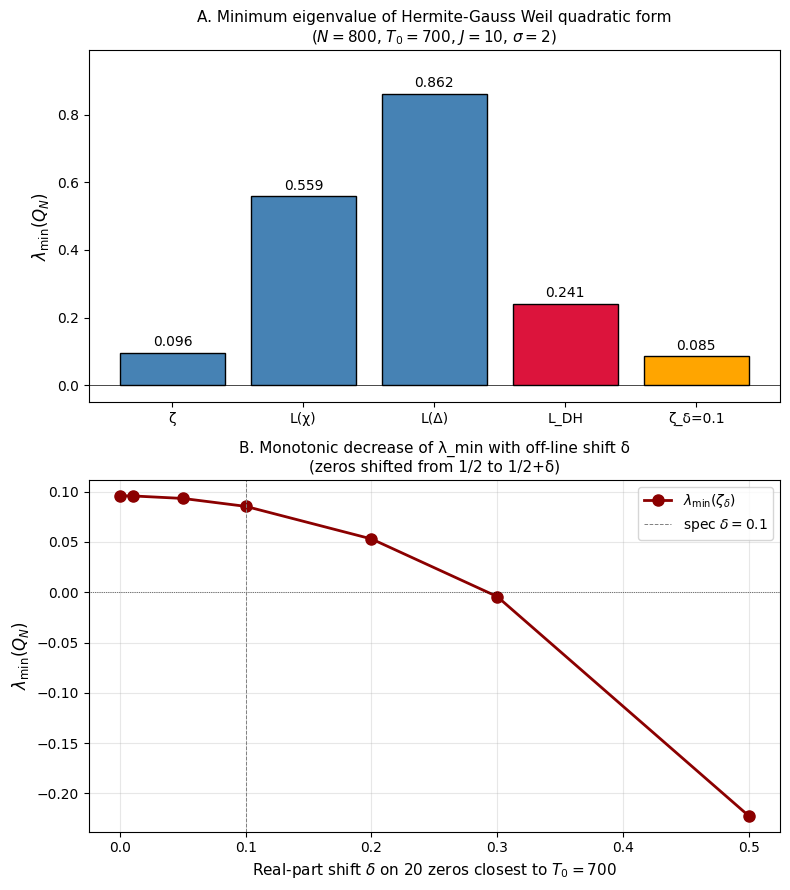

Figure saved to weil_form_results.png


In [47]:

# Now create the final summary figure
import matplotlib.pyplot as plt

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: lambda_min table as bar plot
labels = ['ζ', 'L(χ)', 'L(Δ)', 'L_DH', 'ζ_δ=0.1']
values = [
 np.linalg.eigvalsh(M_zeta).min(),
 np.linalg.eigvalsh(M_lchi_local).min(),
 np.linalg.eigvalsh(M_ldelta_local).min(),
 np.linalg.eigvalsh(M_ldh_local).min(),
 results_zd2[0.1]
]
colors = ['steelblue', 'steelblue', 'steelblue', 'crimson', 'orange']
bars = ax_a.bar(labels, values, color=colors, edgecolor='black')
ax_a.axhline(0, color='black', linewidth=0.5)
ax_a.set_ylabel(r'$\lambda_{\min}(Q_N)$', fontsize=12)
ax_a.set_title('A. Minimum eigenvalue of Hermite-Gauss Weil quadratic form\n'+
 r'($N=800$, $T_0=700$, $J=10$, $\sigma=2$)', fontsize=11)
for bar, v in zip(bars, values):
 ax_a.text(bar.get_x()+bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
ax_a.set_ylim(-0.05, max(values)*1.15)

# Panel B: monotonic variation of zeta_delta with delta
delta_arr = np.array(deltas)
vals_arr = np.array([results_zd2[d] for d in deltas])
ax_b.plot(delta_arr, vals_arr, 'o-', color='darkred', markersize=8, linewidth=2, label=r'$\lambda_{\min}(\zeta_\delta)$')
ax_b.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax_b.axvline(0.1, color='gray', linewidth=0.7, linestyle='--', label=r'spec $\delta=0.1$')
ax_b.set_xlabel(r'Real-part shift $\delta$ on 20 zeros closest to $T_0=700$', fontsize=11)
ax_b.set_ylabel(r'$\lambda_{\min}(Q_N)$', fontsize=12)
ax_b.set_title('B. Monotonic decrease of λ_min with off-line shift δ\n(zeros shifted from 1/2 to 1/2+δ)', fontsize=11)
ax_b.legend(fontsize=10)
ax_b.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('weil_form_results.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved to weil_form_results.png")
